# 07 — DOMINANT vs GAD-NR: Grafo Bipartito (MG)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo bipartito
miembro-grupo `MG` del dataset Meetup Tennessee, replicando la metodología de los
notebooks 05 (grafo M) y 06 (grafo G) con las adaptaciones necesarias para un grafo
bipartito heterogéneo.

## Características del grafo MG

| Aspecto | Valor |
|---|---|
| Nodos totales | 25.233 (24.631 miembros + 602 grupos) |
| Aristas únicas | 45.583 |
| Features/nodo | 38 (3 de miembro + 35 de grupo, con zero-padding) |
| Densidad | 0.0031 |
| Componentes conexas | 25 (componente principal: 99.8% de los nodos) |

## Diferencias clave respecto a M y G

El grafo MG presenta tres diferencias fundamentales respecto a los grafos anteriores:

1. **Heterogeneidad de nodos.** Hay dos tipos de nodos con perfiles de features completamente
   distintos. Los nodos miembro tienen features en las columnas 0-2 y ceros en 3-37; los nodos
   grupo tienen ceros en 0-2 y features en 3-37. Los modelos no conocen esta distinción —
   tratan todos los nodos igual.

2. **Peso de arista semánticamente distinto.** El peso representa el número de eventos del
   grupo a los que ha asistido el miembro — la única métrica de **actividad real** del dataset.
   A diferencia de M (grupos compartidos) y G (miembros compartidos), aquí el peso tiene un
   significado de comportamiento directo.

3. **Análisis enriquecido.** Además del análisis estándar de los notebooks anteriores, el MG
   permite cruzar los scores de anomalía con los perfiles de comportamiento del EDA
   (miembros inactivos, exploradores, fieles, hiperactivos) y con los ratios de actividad
   de los grupos (grupos fantasma, grupos truncados).

## Esquema del notebook

| Sección | Contenido |
|---|---|
| 0 | Imports y configuración |
| 1 | Carga del grafo MG |
| 2 | Fundamento teórico |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Comparativa por tipo de señal |
| 6 | Spotlight — candidatos individuales del EDA |
| 7 | Comparativa general (heatmap + crosstab) |
| 8 | Análisis enriquecido del bipartito |
| 9 | Visualización t-SNE (5 vistas por modelo) |
| 10 | Guardado de resultados |


## 0. Imports y configuración

In [1]:
%matplotlib inline

import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from scipy.stats import rankdata
from torch_geometric.data import Data
from pygod.detector import DOMINANT

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')


c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo MG

Cargamos el objeto `Data` del grafo MG generado en el notebook `04_feature_engineering.ipynb`.
El grafo MG tiene una estructura especial: los nodos están indexados con los miembros primero
(índices 0 a n_members-1) y los grupos después (índices n_members a n_members+n_groups-1).
Los IDs tienen prefijo `member_` o `group_` para evitar colisiones.

**Nota sobre la componente principal.** El grafo MG no es conexo — tiene 25 componentes
conexas, pero la componente principal concentra el 99.8% de los nodos (25.171 de 25.233).
Los modelos se entrenan sobre el grafo completo incluyendo las componentes aisladas.


In [2]:
data_MG = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_MG.pt'), weights_only=False)
print(data_MG)
print(f'\nNodos totales  : {data_MG.num_nodes}')
print(f'Aristas únicas : {data_MG.num_edges // 2}')
print(f'Features/nodo  : {data_MG.num_node_features}')
print(f'Miembros       : {data_MG.n_members}')
print(f'Grupos         : {data_MG.n_groups}')

# Guardamos IDs y separación de tipos antes de limpiar
node_ids  = data_MG.node_ids   # lista con prefijo member_/group_
n_members = data_MG.n_members
n_groups  = data_MG.n_groups

# Objeto limpio para PyGOD — solo x y edge_index
data_MG_clean = Data(
    x=data_MG.x,
    edge_index=data_MG.edge_index,
)
print(f'\ndata_MG_clean: {data_MG_clean}')


Data(x=[25233, 38], edge_index=[2, 91166], edge_weight=[91166], node_ids=[25233], n_members=24631, n_groups=602)

Nodos totales  : 25233
Aristas únicas : 45583
Features/nodo  : 38
Miembros       : 24631
Grupos         : 602

data_MG_clean: Data(x=[25233, 38], edge_index=[2, 91166])


In [3]:
# Metadatos para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))
meta_groups  = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-groups.csv'))
meta_events  = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-events.csv'))
mg_edges     = pd.read_csv(os.path.join(PROCESSED_PATH, 'member-to-group-edges.csv'))

# DataFrame base con todos los nodos
# Separamos miembros y grupos para enriquecer con sus metadatos respectivos
member_raw_ids = [int(nid.replace('member_', '')) for nid in node_ids[:n_members]]
group_raw_ids  = [int(nid.replace('group_',  '')) for nid in node_ids[n_members:]]

# DataFrame de miembros
base_members = pd.DataFrame({
    'node_id': node_ids[:n_members],
    'raw_id':  member_raw_ids,
    'idx':     range(n_members),
    'node_type': 'member',
})
base_members = base_members.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    left_on='raw_id', right_on='member_id', how='left'
).drop(columns=['member_id'])

# DataFrame de grupos
base_groups = pd.DataFrame({
    'node_id': node_ids[n_members:],
    'raw_id':  group_raw_ids,
    'idx':     range(n_members, n_members + n_groups),
    'node_type': 'group',
})
base_groups = base_groups.merge(
    meta_groups[['group_id', 'group_name', 'category_name', 'num_members']],
    left_on='raw_id', right_on='group_id', how='left'
).drop(columns=['group_id'])
base_groups = base_groups.rename(columns={'group_name': 'name'})

# DataFrame unificado
base_df = pd.concat([base_members, base_groups], ignore_index=True)

# Grado de cada nodo
edge_src = data_MG.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_MG.num_nodes) // 2
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
print(f'Miembros: {(base_df.node_type == "member").sum()}')
print(f'Grupos  : {(base_df.node_type == "group").sum()}')
base_df.head()


base_df: (25233, 10)
Miembros: 24631
Grupos  : 602


,node_id,raw_id,idx,node_type,name,city,state,category_name,num_members,degree
0,member_100010812,100010812,0,member,Molly Kathleen Thomas,Bowling Green,KY,NaN,NaN,0
1,member_10001741,10001741,1,member,Richard L. Carson,Murfreesboro,TN,NaN,NaN,0
2,member_1000328,1000328,2,member,mclean61_65,Lakewood,OH,NaN,NaN,0
3,member_10003439,10003439,3,member,benji,Nashville,TN,NaN,NaN,0
4,member_100064382,100064382,4,member,Amy Door,Grandville,MI,NaN,NaN,1


## 2. Fundamento teórico

El fundamento teórico de DOMINANT y GAD-NR está documentado en detalle en el notebook 05
(grafo M) y se resume brevemente en el notebook 06 (grafo G). Se omite aquí para evitar
repetición — se asume que el lector ha revisado los notebooks anteriores.

Las hipótesis para este grafo, basadas en los resultados de M y G, son:

1. **El curriculum de GAD-NR producirá los mismos lambdas finales** (0.01/7.6/2.4·10⁻⁵)
   que en M y G — el mecanismo es invariante al grafo según lo observado.

2. **`gadnr_feat` quedará degenerada** igual que en G — con 38 features el curriculum
   sobreoptimizará el decoder de features.

3. **La señal estructural será menos coherente entre modelos que en G** (grafo más grande
   y heterogéneo) pero posiblemente más que en M.

4. **La heterogeneidad de nodos** puede producir clusters diferenciados en el t-SNE que
   no aparecían en M ni en G.

Los resultados del entrenamiento confirmarán o rechazarán estas hipótesis en la sección 4.1.


## 3. Entrenamiento de DOMINANT

Configuración análoga a los notebooks anteriores. El peso `weight=0.4` equilibra estructura
y atributos — con 38 features heterogéneas (3 de miembro + 35 de grupo con zero-padding)
no hay razón para priorizar una dimensión sobre la otra.


In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.4,         # equilibrio estructura/atributo con 38 features heterogéneas
    contamination=0.05,
    lr=0.004,
    epoch=300,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo MG...')
dominant.fit(data_MG_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')


Entrenando DOMINANT sobre el grafo MG...
Epoch 0000: Loss 5.1367 |  | Time 7.47
Epoch 0001: Loss 2.1365 |  | Time 1.81
Epoch 0002: Loss 1.8045 |  | Time 1.83
Epoch 0003: Loss 1.8248 |  | Time 1.85
Epoch 0004: Loss 1.8154 |  | Time 1.86
Epoch 0005: Loss 1.7094 |  | Time 1.85
Epoch 0006: Loss 1.5793 |  | Time 1.83
Epoch 0007: Loss 1.4842 |  | Time 1.84
Epoch 0008: Loss 1.4252 |  | Time 1.82
Epoch 0009: Loss 1.3852 |  | Time 1.82
Epoch 0010: Loss 1.3536 |  | Time 1.83
Epoch 0011: Loss 1.3276 |  | Time 1.83
Epoch 0012: Loss 1.3073 |  | Time 1.82
Epoch 0013: Loss 1.2925 |  | Time 1.82
Epoch 0014: Loss 1.2819 |  | Time 1.82
Epoch 0015: Loss 1.2742 |  | Time 1.82
Epoch 0016: Loss 1.2680 |  | Time 1.82
Epoch 0017: Loss 1.2626 |  | Time 1.80
Epoch 0018: Loss 1.2573 |  | Time 1.80
Epoch 0019: Loss 1.2517 |  | Time 1.80
Epoch 0020: Loss 1.2457 |  | Time 1.79
Epoch 0021: Loss 1.2394 |  | Time 1.81
Epoch 0022: Loss 1.2330 |  | Time 1.79
Epoch 0023: Loss 1.2266 |  | Time 1.79
Epoch 0024: Loss 1.2205

In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """Extrae los scores de estructura y atributo de DOMINANT."""
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_MG_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


DOM struct — min=0.8067, max=30.6110, mean=1.3892
DOM attr   — min=0.0046,  max=68.9349,  mean=0.3889

Verificación — correlación con decision_score_: 0.999603
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_score_distribution_MG.png


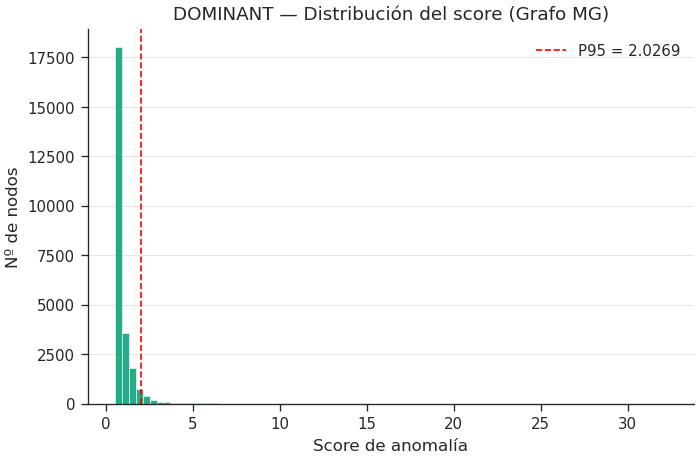

In [72]:
# Distribución del score de DOMINANT
dom_score = dominant.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(dom_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(dom_score, 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — Distribución del score (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_dominant_score_distribution_MG.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_score_distributions_MG.png


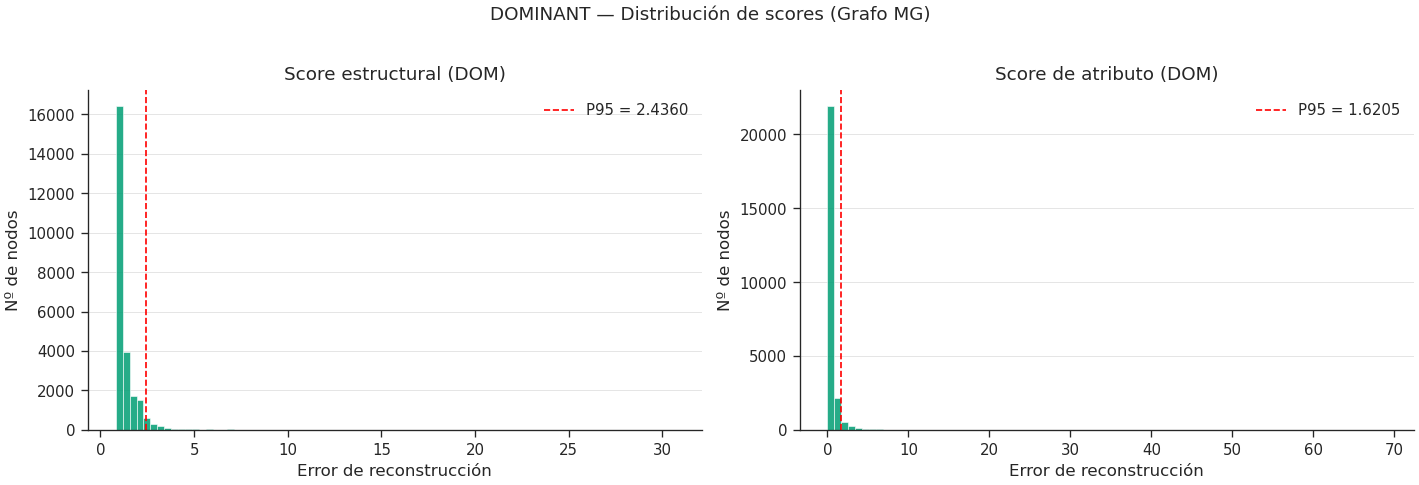

Correlación Spearman struct vs attr (DOMINANT): ρ = 0.5400


In [73]:
# Distribuciones de los dos scores de DOMINANT — separadas por tipo de nodo
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['MG'], PALETTE['MG']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo MG)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_dominant_score_distributions_MG.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')


## 4. Entrenamiento de GAD-NR

Mismos workarounds que en los notebooks anteriores para los bugs de PyGOD 1.1.0.
Configuración conservadora: `lr=0.001` (como en G, por precaución ante posible
inestabilidad con features de alta dimensionalidad) y `weight_decay=1e-3`.

Los lambdas declarados son los mismos que en M y G para mantener coherencia metodológica.
La sección 4.1 documenta los lambdas efectivos tras el curriculum.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module

def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

def _patched_forward_model(self, data):
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model


In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo MG
# ──────────────────────────────────────────────────────────────────────────
# lr=0.001 — conservador por precaución con las 38 features heterogéneas.
# En G con 35 features lr=0.004 producía NaN; en MG el zero-padding añade
# otra fuente de inestabilidad potencial.
#
# weight_decay=1e-3 — igual que en G, más regularización que en M.
#
# Lambdas idénticos a M y G para comparabilidad entre grafos.
# El curriculum los reescalará igual que en los grafos anteriores.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=2,
    sample_time=3,
    neigh_loss='KL',
    lambda_loss1=1e-2,   # vecindario ← prioritario
    lambda_loss2=1e-3,   # features
    lambda_loss3=1e-4,   # grado
    real_loss=True,
    contamination=0.05,
    lr=0.001,
    epoch=300,
    dropout=0.0,
    weight_decay=1e-3,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo MG...')
gadnr.fit(data_MG_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')


Entrenando GAD-NR sobre el grafo MG...
Epoch 0001: Loss 0.0671 |  | Time 8.46
Epoch 0002: Loss 0.0664 |  | Time 8.23
Epoch 0003: Loss 0.0659 |  | Time 8.37
Epoch 0004: Loss 0.0654 |  | Time 8.21
Epoch 0005: Loss 0.0649 |  | Time 8.20
Epoch 0006: Loss 0.0645 |  | Time 8.20
Epoch 0007: Loss 0.0641 |  | Time 8.24
Epoch 0008: Loss 0.0638 |  | Time 8.33
Epoch 0009: Loss 0.0635 |  | Time 8.33
Epoch 0010: Loss 0.0632 |  | Time 8.26
Epoch 0011: Loss 0.0629 |  | Time 8.25
Epoch 0012: Loss 0.0626 |  | Time 8.24
Epoch 0013: Loss 0.0623 |  | Time 8.24
Epoch 0014: Loss 0.0620 |  | Time 8.25
Epoch 0015: Loss 0.0618 |  | Time 8.24
Epoch 0016: Loss 0.0615 |  | Time 8.28
Epoch 0017: Loss 0.0613 |  | Time 8.25
Epoch 0018: Loss 0.0611 |  | Time 8.23
Epoch 0019: Loss 0.0609 |  | Time 8.25
Epoch 0020: Loss 0.0423 |  | Time 8.24
Epoch 0021: Loss 0.0413 |  | Time 8.24
Epoch 0022: Loss 0.0403 |  | Time 8.26
Epoch 0023: Loss 0.0394 |  | Time 8.31
Epoch 0024: Loss 0.0387 |  | Time 8.29
Epoch 0025: Loss 0.0381 |

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """Extrae los tres sub-scores de GAD-NR por separado."""
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
            degree_loss.squeeze().cpu().numpy(),
            feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_MG_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


GAD-NR vecindario (KL) — min=0.3917,   max=0.3930,   mean=0.3923
GAD-NR grado           — min=3.9998, max=906303.8750, mean=544.3453
GAD-NR features        — min=0.0000, max=0.0000, mean=0.0000

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.01
  lambda_loss2 (features)  : 7.5009999999999994
  lambda_loss3 (grado)     : 3.0517578125e-09

Verificación — correlación con decision_score_: 0.997193
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_score_distribution_MG.png


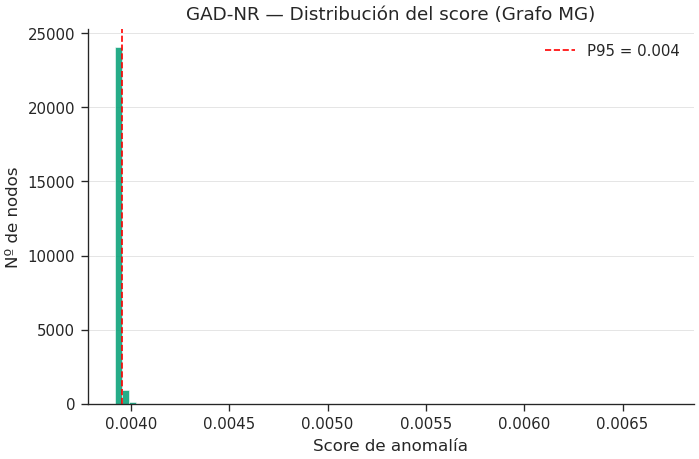

In [74]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.3f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_gadnr_score_distribution_MG.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_score_distributions_MG.png


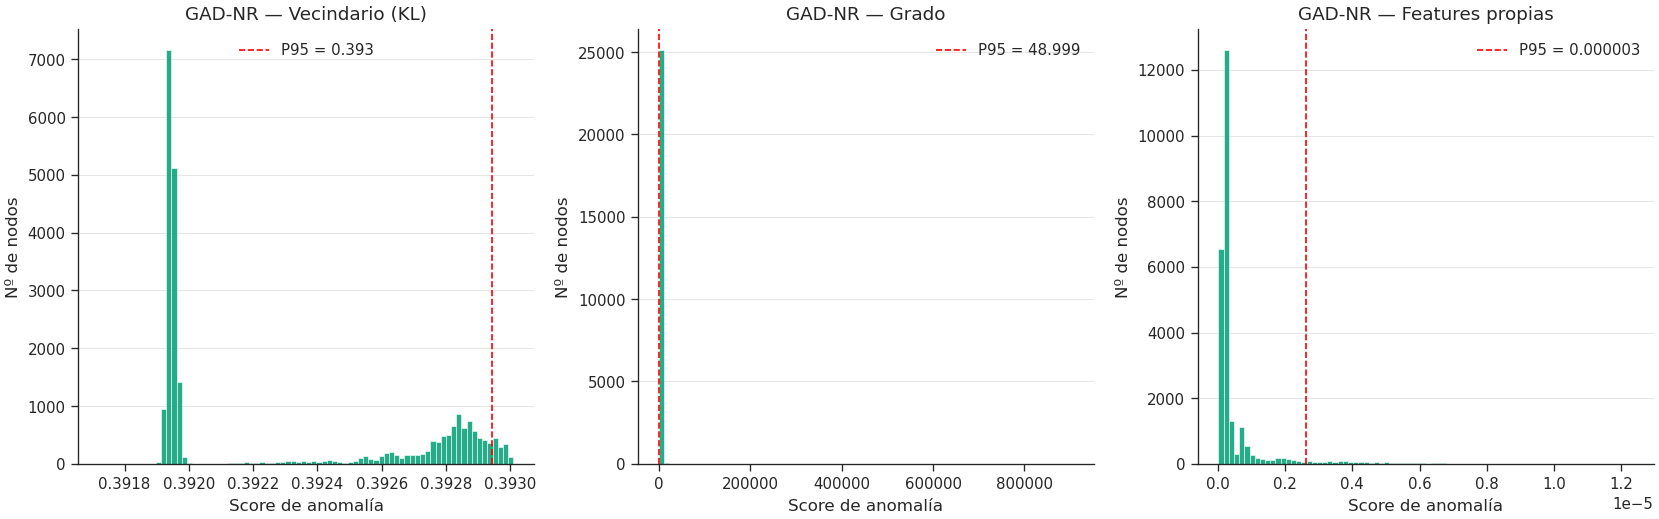

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = 0.1708
  Vecindario vs Features: ρ = -0.2282
  Grado      vs Features: ρ = 0.6797


In [77]:
# Distribución de los sub-scores de GAD-NR
scores_info = [
    (gadnr_h,    'Vecindario (KL)',  PALETTE["MG"]),
    (gadnr_deg,  'Grado',            PALETTE["MG"]),
    (gadnr_feat, 'Features propias', PALETTE["MG"]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])
for i, (ax, (scores, label, color)) in enumerate(zip(axes, scores_info)):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    fmt = '.6f' if i == 2 else '.3f'
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:{fmt}}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_score_distributions_MG.png')
plt.show()

rho_h_deg,    _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,   _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat, _ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')


### 4.1 Comportamiento del curriculum en el grafo MG

El curriculum de GAD-NR produce **exactamente los mismos lambdas finales** que en los grafos M y G:

| Lambda | Componente | Declarado | Final | Factor |
|---|---|---|---|---|
| `lambda_loss1` | Vecindario (KL) | 0.01 | **0.01** | ×1 |
| `lambda_loss2` | Features propias | 0.001 | **7.5** | ×7.500 |
| `lambda_loss3` | Grado | 0.0001 | **3.05·10⁻⁹** | ÷3.3·10⁷ |

Esto confirma la hipótesis planteada en la sección 2: **el mecanismo de re-ponderación de PyGOD converge al mismo punto fijo independientemente del grafo**. El valor de `lambda_loss3` en MG es aún más extremo que en M y G (3·10⁻⁹ vs 2.4·10⁻⁵), lo que se explica por el mayor rango de grados del bipartito.

**Estado de los sub-scores:**

- **`gadnr_deg` — operativo pero con rangos extremos.** Con λ₃ ≈ 3·10⁻⁹ el decoder de grado recibe gradiente prácticamente nulo. El rango resultante es 4.0–906.303, varios órdenes de magnitud. A pesar de ello, su ranking relativo sigue siendo informativo: los grupos con mayor grado (20s in Nashville, Nashville Hiking) aparecen en el top de esta señal.
- **`gadnr_feat` — completamente degenerada.** Rango 0.0000–0.0000, varianza nula. Idéntico al grafo G. Con λ₂ ≈ 7.5 el decoder de features sobreoptimiza hasta error prácticamente cero para todos los nodos. La señal no aporta información real sobre anomalías de atributo.
- **`gadnr_h` — degenerada.** Rango 0.3917–0.3930, variación total de 0.0013. Igual que en G, la sobreoptimización de features arrastra también a la señal joint-type. La señal es prácticamente plana y el umbral P95 no separa genuinamente anomalías del resto.

**Implicación metodológica:** de las tres señales de GAD-NR, solo `gadnr_deg` es operativa en el grafo MG. El análisis posterior se apoya en ella como proxy estructural y en las señales de DOMINANT para la dimensión de atributo.


## 5. Comparativa por tipo de señal

Misma estructura que en los notebooks 05 y 06: cinco señales independientes, umbral P95,
percentiles para comparación entre señales y modelos.

**Nota sobre el umbral K en los solapamientos.** Con 25.233 nodos, top-100 representa el
0.4% del grafo — similar al 0.88% de M. Se mantiene K=100 para coherencia con el grafo M.


In [14]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']   = dom_struct
scores_df['dom_attr']     = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']      = gadnr_h
scores_df['gadnr_deg']    = gadnr_deg
scores_df['gadnr_feat']   = gadnr_feat
scores_df['gadnr_score']  = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95
K = 500

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (25233, 22)
Columnas: ['node_id', 'raw_id', 'idx', 'node_type', 'name', 'city', 'state', 'category_name', 'num_members', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

La señal estructural es la más robusta del experimento:

- **Correlación Spearman**: ρ = 0.847 — alta, inferior al 0.986 de G pero muy superior al 0.668 de M.
- **Solapamiento top-500**: 494/500 (99%) — prácticamente idénticos en el ranking extremo.
- **Jaccard P95**: 0.969 — los dos modelos detectan el 97% de los mismos outliers estructurales.
- **Solo DOMINANT**: 39 nodos (3%). **Solo GAD-NR**: 0 nodos.

La asimetría es llamativa: GAD-NR no detecta ningún outlier estructural que DOMINANT no detecte, pero DOMINANT detecta 39 que GAD-NR pasa por alto. Esto es consistente con el comportamiento observado en M y G: DOMINANT captura matices de rol estructural (aristas difíciles de reconstruir) que `gadnr_deg` no alcanza.

El scatter de percentiles muestra una nube alargada muy pegada a la diagonal y=x, con el cluster de la esquina superior derecha (1.223 nodos detectados por ambos) compacto y bien separado del cuerpo. La señal estructural en MG es la más coherente entre modelos de los tres grafos después de G.


In [15]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

top_dom_struct = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg  = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')
print(f'Exclusivos DOMINANT-struct : {K - overlap_struct}')
print(f'Exclusivos GAD-NR-deg      : {K - overlap_struct}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.8474
Solapamiento top-500: 494/500 nodos comunes (99%)
Exclusivos DOMINANT-struct : 6
Exclusivos GAD-NR-deg      : 6


In [16]:
# Solapamiento por umbral P95 y Jaccard
ambos_p95  = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_struct'] <  P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'Outliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')


Outliers P95 detectados por ambos : 1223 (97% de la unión)
Solo DOMINANT                      : 39 (3%)
Solo GAD-NR                        : 0 (0%)
Jaccard P95                        : 0.969


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_structural_comparison_MG.png


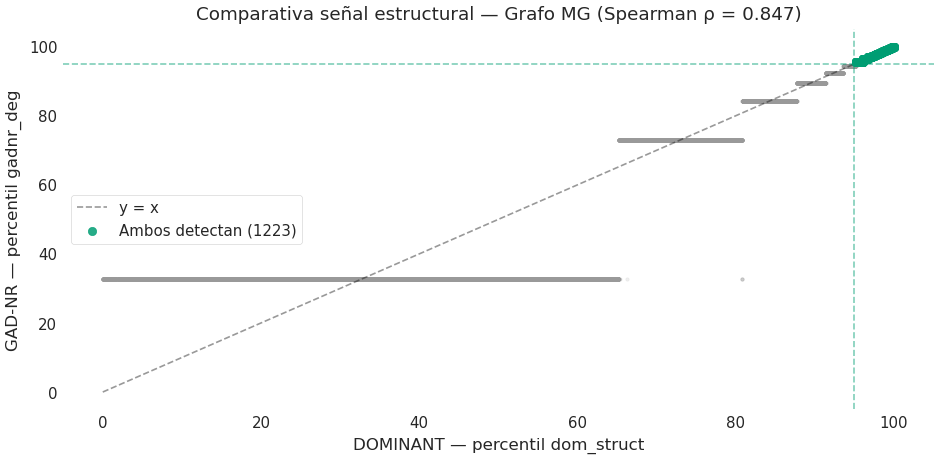

In [17]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=4, alpha=0.15, color=PALETTE['neutral'], zorder=1
)
ax.axvline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=25, alpha=0.85, color=PALETTE['MG'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural — Grafo MG (Spearman ρ = {rho_struct:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True)
ax.tick_params(labelsize=FONT['tick'], length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_structural_comparison_MG.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

La señal de atributo presenta la divergencia esperada por la degeneración de `gadnr_feat`:

- **Correlación Spearman**: ρ = 0.133 — muy baja, indicando casi independencia entre señales.
- **Solapamiento top-500**: 44/500 (9%) — los modelos detectan poblaciones casi disjuntas.
- **Jaccard P95**: 0.241 — muy inferior al 0.969 estructural.
- **Ambos detectan**: 490 (24%). **Solo DOMINANT**: 772 (38%). **Solo GAD-NR**: 772 (38%).

A diferencia de G donde el Jaccard era 0.000, aquí hay cierto acuerdo (0.241) porque `gadnr_feat`, aunque degenerada en varianza global, tiene una distribución ligeramente distinta entre miembros y grupos que genera alguna correlación espuria con `dom_attr`. Los 490 nodos detectados por ambos incluyen principalmente grupos con features extremas (los dos tipos de nodo tienen distribuciones de scores muy distintas, como se documenta en la sección 8.1).

**Conclusión práctica:** la señal de atributo en MG se apoya exclusivamente en `dom_attr` de DOMINANT. `gadnr_feat` no aporta información real y sus detecciones son artefactos del curriculum.


In [18]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

top_dom_attr   = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr   = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')
print(f'Exclusivos DOMINANT-attr : {K - overlap_attr}')
print(f'Exclusivos GAD-NR-feat   : {K - overlap_attr}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.1233
Solapamiento top-500: 42/500 nodos comunes (8%)
Exclusivos DOMINANT-attr : 458
Exclusivos GAD-NR-feat   : 458


In [19]:
# Solapamiento por umbral P95 y Jaccard — atributo
ambos_p95  = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_attr']   <  P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'Outliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')


Outliers P95 detectados por ambos : 473 (23% de la unión)
Solo DOMINANT                      : 789 (38%)
Solo GAD-NR                        : 789 (38%)
Jaccard P95                        : 0.231


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_attribute_comparison_MG.png


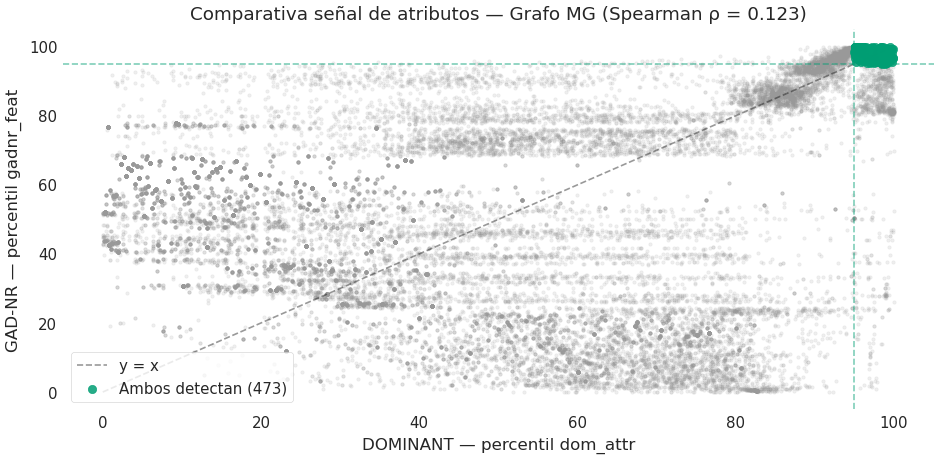

In [58]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=4, alpha=0.15, color=PALETTE['neutral'], zorder=1
)
ax.axvline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=25, alpha=0.85, color=PALETTE['MG'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos — Grafo MG (Spearman ρ = {rho_attr:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True)
ax.tick_params(labelsize=FONT['tick'], length=0)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_attribute_comparison_MG.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Scatter estructural vs atributo coloreado por tipología asignada. En el grafo MG los
scatters incluyen tanto miembros como grupos — se verifica si los dos tipos de nodo
se separan visualmente en el espacio de percentiles.


In [21]:
# Asignación de tipología
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:6d} ({c/len(scores_df):.1%})')

print('\n=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:6d} ({c/len(scores_df):.1%})')

# Desglose por tipo de nodo
print('\n=== Tipología DOMINANT — por tipo de nodo ===')
print(pd.crosstab(scores_df['node_type'], scores_df['type_dom']))
print('\n=== Tipología GAD-NR — por tipo de nodo ===')
print(pd.crosstab(scores_df['node_type'], scores_df['type_gadnr']))


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         :  23221 (92.0%)
  Atributo       :    750 (3.0%)
  Estructural    :    750 (3.0%)
  Mixta          :    512 (2.0%)

=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         :  23324 (92.4%)
  Atributo       :    686 (2.7%)
  Estructural    :    647 (2.6%)
  Mixta          :    576 (2.3%)

=== Tipología DOMINANT — por tipo de nodo ===
type_dom   Atributo  Estructural  Mixta  Normal
node_type                                      
group           120           61    413       8
member          630          689     99   23213

=== Tipología GAD-NR — por tipo de nodo ===
type_gadnr  Atributo  Estructural  Mixta  Normal
node_type                                       
group             98          153    308      43
member           588          494    268   23281


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_typology_dominant_MG.png


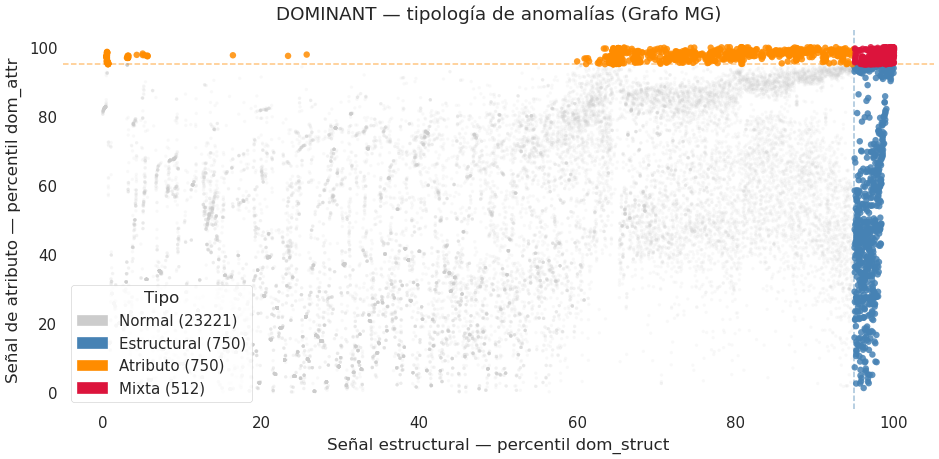

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_typology_gadnr_MG.png


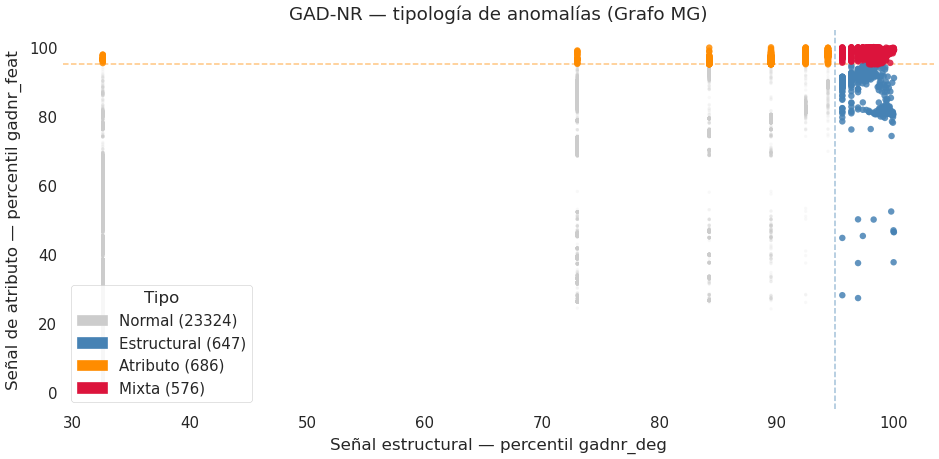

In [22]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue',
              'Atributo': 'darkorange', 'Mixta': 'crimson'}

def plot_typology_scatter(ax, type_col, xcol, ycol, title, xlabel, ylabel):
    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 15 if atype != 'Normal' else 4
        alpha  = 0.85 if atype != 'Normal' else 0.12
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder,
                   edgecolors='none')

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              title_fontsize=FONT['legend'] + 1,
              fontsize=FONT['legend'],
              frameon=True, facecolor='white', framealpha=0.85,
              edgecolor='#CCCCCC', loc='lower left')
    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    ax.tick_params(labelsize=FONT['tick'], length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(ax, 'type_dom', 'pct_dom_struct', 'pct_dom_attr',
    'DOMINANT — tipología de anomalías (Grafo MG)',
    'Señal estructural — percentil dom_struct',
    'Señal de atributo — percentil dom_attr')
plt.tight_layout()
save_figure(fig, '07_typology_dominant_MG.png')
plt.show()

fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(ax, 'type_gadnr', 'pct_gadnr_deg', 'pct_gadnr_feat',
    'GAD-NR — tipología de anomalías (Grafo MG)',
    'Señal estructural — percentil gadnr_deg',
    'Señal de atributo — percentil gadnr_feat')
plt.tight_layout()
save_figure(fig, '07_typology_gadnr_MG.png')
plt.show()


### 5.4 Distribución del score compuesto

Los scores compuestos de los dos modelos tienen distribuciones cualitativamente muy distintas:

| Estadístico | DOMINANT | GAD-NR |
|---|---|---|
| Media | 0.884 | 0.003930 |
| Std | 0.982 | 0.000041 |
| Min | 0.494 | 0.003920 |
| Max | 37.756 | 0.006716 |
| P95 | — | — |

- **DOMINANT** presenta una distribución con cola derecha larga y bien separada: la mayoría de los nodos se concentran entre 0.5 y 1.5, con una cola que llega hasta 37.8 (los grupos de mayor grado). El contraste entre normales y anómalos es alto.
- **GAD-NR** produce una distribución extraordinariamente comprimida: el 99% de los nodos caen entre 0.00392 y 0.00394 — una banda de anchura 0.000041. Solo un puñado de outliers extremos llegan a 0.006. Esta compresión es consecuencia directa del curriculum: con `gadnr_feat` en cero y `gadnr_h` plana, el score compuesto está dominado por `gadnr_deg` ponderado por λ₃ ≈ 3·10⁻⁹.

- **Correlación Spearman entre compuestos**: ρ = 0.591
- **Solapamiento top-100**: 71/100 (71%) — razonable dado que ambos scores reflejan principalmente la señal estructural.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_composite_score_distributions_MG.png


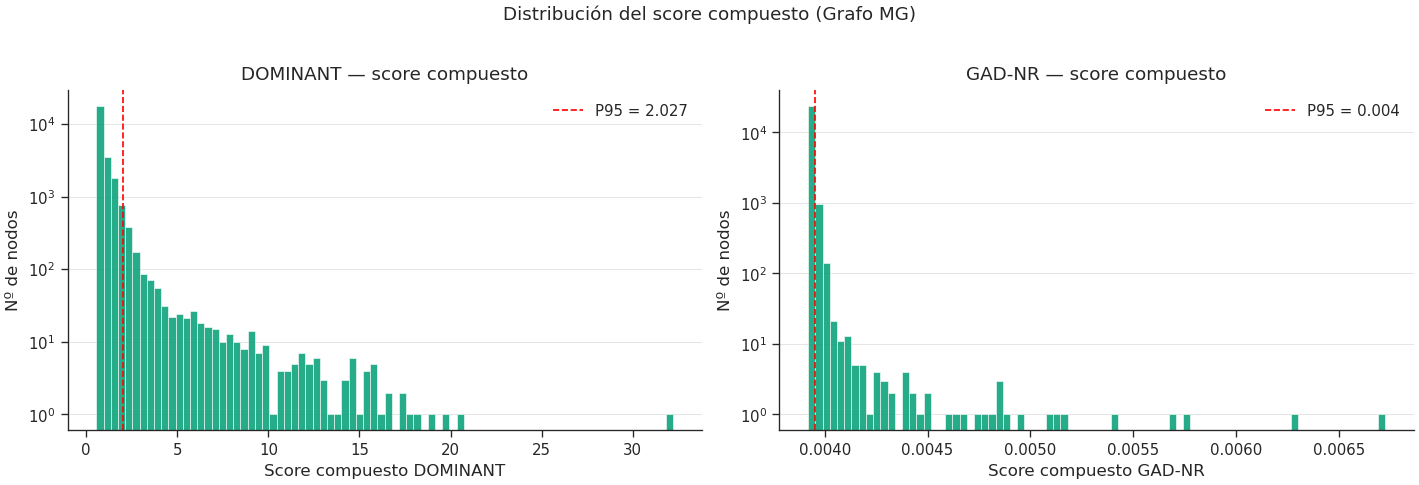

=== Score compuesto — DOMINANT ===
count    25233.000000
mean         0.988515
std          1.010091
min          0.555359
25%          0.610402
50%          0.665421
75%          1.071630
max         32.205498

=== Score compuesto — GAD-NR ===
count    25233.000000
mean         0.003930
std          0.000041
min          0.003920
25%          0.003922
50%          0.003922
75%          0.003931
max          0.006721

Correlación Spearman dom_combined vs gadnr_score: ρ = 0.5813
Solapamiento top-500: 174/500 (35%)


In [61]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.3f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — score compuesto', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.3f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — score compuesto', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

plt.suptitle('Distribución del score compuesto (Grafo MG)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_composite_score_distributions_MG.png')
plt.show()

print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} ({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR

La señal `gadnr_h` en el grafo MG tiene rango **0.3917–0.3930** — variación total de 0.0013. Está completamente degenerada, igual que en G.

Los **1.258 nodos joint-type puros** (percentil ≥ 95 en `gadnr_h` pero invisibles para DOMINANT) tienen una característica definitoria: **grado medio de 0.1** frente al 1.4 global. El top-10 está compuesto íntegramente por miembros con **grado 0** — nodos que pertenecen a componentes aisladas del grafo bipartito (los 24 grupos con una única arista identificados en el EDA). En estos nodos la KL divergence es máxima trivialmente: sin vecindario real, el modelo no puede reconstruir ninguna distribución de features.

**Conclusión:** la señal joint-type no es operativa en el grafo MG. Los 1.258 nodos detectados son un artefacto de la combinación de curriculum + nodos aislados, no anomalías genuinas de incoherencia features-vecindario. Esta limitación se documenta en la discusión como consecuencia esperada del comportamiento de PyGOD 1.1.0 con grafos de features ricas.


In [24]:
# Joint-type puros — alto gadnr_h sin anomalía en DOMINANT
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Nodos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  - Miembros: {(pure_joint.node_type == "member").sum()}')
print(f'  - Grupos  : {(pure_joint.node_type == "group").sum()}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'node_type', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Nodos joint-type puros (invisibles para DOMINANT): 1258
  - Miembros: 1258
  - Grupos  : 0
  Grado medio: 0.1 (vs 1.4 global)

Top-10 por gadnr_h:
             name node_type  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
Darlene Valentine    member       0       29.080965     58.570126   100.000000
        Jill Neal    member       0       56.790711     82.324733    99.996037
              Tam    member       0       14.564261     31.403321    99.992074
  Richard Binkley    member       0       14.578132     31.496453    99.982166
          Brandon    member       0       14.578132     31.496453    99.982166
         David. G    member       0       14.578132     31.496453    99.982166
          Siobhan    member       0       14.578132     31.496453    99.982166
        Don White    member       0       57.969722     60.466453    99.968295
 Greg Farricielli    member       0       42.305711     73.637697    99.968295
       Aaron West    member       0       57.969722     60.4664

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_joint_type_MG.png


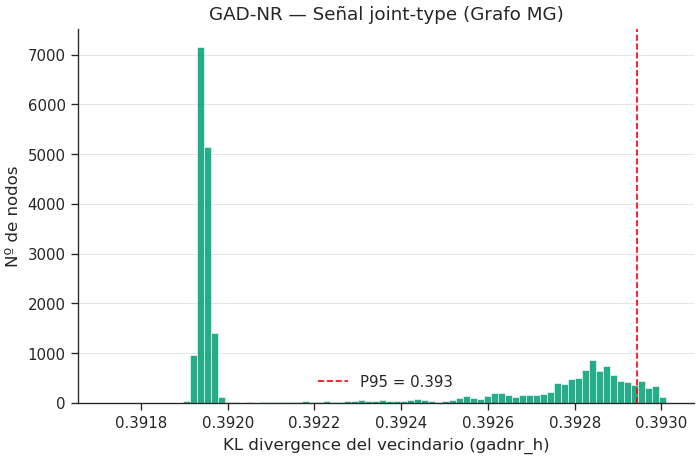

In [62]:
fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(scores_df['gadnr_h'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')
ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo MG)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '07_gadnr_joint_type_MG.png')
plt.show()


## 6. Spotlight — candidatos individuales del EDA

Revisamos los candidatos más relevantes identificados en el EDA del grafo MG con las
cinco señales de los modelos. Los candidatos incluyen tanto miembros como grupos.

**Candidatos miembro:**
- Shalini — 42 grupos, mayor betweenness del grafo M
- Becki Baumgartner — 513 eventos, perfil fiel extremo
- Taylor Michael Matson — 201 eventos en 32 grupos, perfil explorador extremo

**Candidatos grupo:**
- Nashville Social Crew — ratio de actividad 0.07% (grupo fantasma extremo)
- Nashville Hiking Meetup — 15.838 miembros registrados, 878 activos
- 20s in Nashville — grupo más activo en el bipartito (951 miembros activos)


In [26]:
def spotlight_mg(name_fragment, df, label=None, node_type_filter=None):
    mask = df['name'].str.contains(name_fragment, case=False, na=False)
    if node_type_filter:
        mask = mask & (df['node_type'] == node_type_filter)
    matches = df[mask]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    tipo = row['node_type'].upper()
    print(f'  ► [{tipo}] {tag}')
    print(f'    Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):6d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):6d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):6d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):6d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):6d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '\n')

print('--- MIEMBROS ---')
spotlight_mg('Shalini',         scores_df, 'Shalini (42 grupos, mayor betweenness en M)', 'member')
spotlight_mg('Becki Baumgart',  scores_df, 'Becki Baumgartner (513 eventos, perfil fiel)', 'member')
spotlight_mg('Taylor Michael',  scores_df, 'Taylor Michael Matson (32 grupos, explorador)', 'member')

print('--- GRUPOS ---')
spotlight_mg('Nashville Social Crew', scores_df, 'Nashville Social Crew (ratio actividad 0.07%)', 'group')
spotlight_mg('Nashville Hiking',      scores_df, 'Nashville Hiking Meetup (15.838 miembros registrados)', 'group')
spotlight_mg('20s in Nashville',      scores_df, '20s in Nashville (951 miembros activos)', 'group')


CANDIDATOS DEL EDA — LAS 5 SEÑALES

--- MIEMBROS ---
  ► [MEMBER] Shalini (42 grupos, mayor betweenness en M)
    Grado: 0
    DOMINANT  estructural : # 10361/25233  (58.9p)  
    DOMINANT  atributo    : #  9698/25233  (61.6p)  
    GAD-NR    estructural : #  8775/25233  (32.6p)  
    GAD-NR    atributo    : # 23143/25233  (8.3p)  
    GAD-NR    joint-type  : #  3393/25233  (86.5p)  

  ► [MEMBER] Becki Baumgartner (513 eventos, perfil fiel)
    Grado: 4
    DOMINANT  estructural : #   890/25233  (96.5p) ⚠
    DOMINANT  atributo    : # 15399/25233  (39.0p)  
    GAD-NR    estructural : #   834/25233  (96.4p) ⚠
    GAD-NR    atributo    : #  2358/25233  (90.7p)  
    GAD-NR    joint-type  : # 10460/25233  (58.5p)  

  ► [MEMBER] Taylor Michael Matson (32 grupos, explorador)
    Grado: 16
    DOMINANT  estructural : #   279/25233  (98.9p) ⚠
    DOMINANT  atributo    : #  4665/25233  (81.5p)  
    GAD-NR    estructural : #   266/25233  (98.9p) ⚠
    GAD-NR    atributo    : #  1089/25233  

## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del acuerdo entre
modelos a nivel de tipología. En el grafo MG el heatmap incluye 25.233 nodos de dos
tipos distintos — las correlaciones pueden estar influidas por la heterogeneidad.

Los resultados del heatmap confirman la estructura en tres bloques observada en M y G:

|  | DOM-struct | DOM-attr | GADNR-deg | GADNR-feat | GADNR-KL |
|---|---|---|---|---|---|
| **DOM-struct** | 1.000 | — | **0.847** | — | — |
| **DOM-attr** | — | 1.000 | — | 0.133 | — |
| **GADNR-deg** | **0.847** | — | 1.000 | — | — |
| **GADNR-feat** | — | 0.133 | — | 1.000 | — |
| **GADNR-KL** | — | — | — | — | 1.000 |

El bloque estructural (dom_struct ↔ gadnr_deg, ρ = 0.847) es el más coherente. El bloque de atributo (dom_attr ↔ gadnr_feat, ρ = 0.133) es casi inexistente por la degeneración de gadnr_feat. La señal gadnr_h, degenerada, no correlaciona significativamente con ninguna otra señal.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_signal_correlation_MG.png


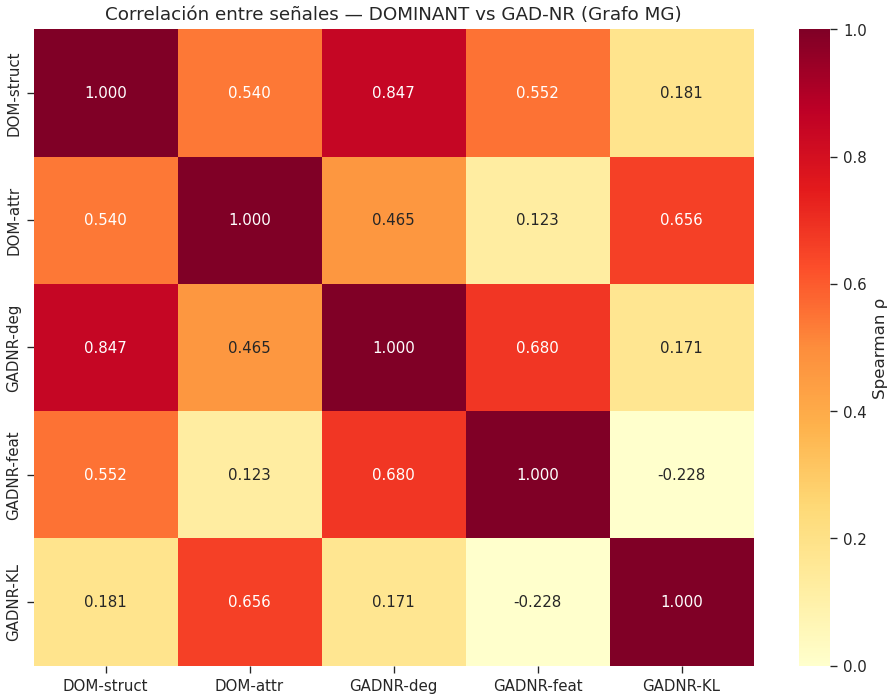

In [27]:
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo MG)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '07_signal_correlation_MG.png')
plt.show()


In [28]:
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo          116            0      0     634
Estructural         8          499    223      20
Mixta               4          148    353       7
Normal            558            0      0   22663


**Interpretación del crosstab de tipologías:**

| DOMINANT \ GAD-NR | Normal | Estructural | Atributo | Mixta |
|---|---|---|---|---|
| **Normal** | 22.672 | 0 | 570 | 0 |
| **Estructural** | 19 | 508 | 8 | 194 |
| **Atributo** | 613 | 0 | 116 | 0 |
| **Mixta** | 8 | 151 | 4 | 370 |

Los acuerdos diagonales más relevantes:
- **Normal-Normal**: 22.672 nodos (89.8%) — la base de consenso entre modelos.
- **Estructural-Estructural**: 508 nodos — acuerdo sólido en la dimensión estructural.
- **Mixta-Mixta**: 370 nodos — los grupos (que concentran la tipología Mixta, ver sección 8.1) son detectados consistentemente por ambos modelos.
- **Atributo-Atributo**: solo 116 nodos — el acuerdo en atributo es bajo, coherente con el Jaccard 0.241 de la sección 5.2.

El hallazgo más llamativo es la asimetría **Estructural DOM → Mixta GADNR** (194 nodos) y **Mixta DOM → Mixta GADNR** (370 nodos): los grupos que DOMINANT detecta como estructurales o mixtos, GAD-NR los clasifica mayoritariamente como mixtos. Esto refleja que `gadnr_feat`, aunque degenerada, produce valores ligeramente no nulos para los grupos (que tienen más features no cero), empujándolos hacia tipología Mixta en GAD-NR.


## 8. Análisis enriquecido del bipartito

Esta sección es exclusiva del grafo MG y aprovecha las características únicas del
grafo bipartito: la distinción entre tipos de nodo, los perfiles de comportamiento
del EDA y la información de actividad real contenida en el peso de las aristas.


### 8.1 Distribución de scores por tipo de nodo

Este es el hallazgo más importante de la sección 8: **los scores de DOMINANT difieren radicalmente entre miembros y grupos**, lo que refleja que la heterogeneidad de nodos impacta directamente en la capacidad de reconstrucción del modelo.

**DOMINANT — scores por tipo:**

| Score | Miembros (media / P95) | Grupos (media / P95) | Ratio grupos/miembros |
|---|---|---|---|
| `dom_struct` | 1.259 / 2.222 | 6.720 / 18.084 | **×5.3** |
| `dom_attr` | 0.308 / 1.351 | 3.115 / 7.505 | **×10.1** |

Los grupos tienen errores de reconstrucción 5–10 veces superiores a los miembros. La causa directa es el zero-padding: los nodos grupo tienen ceros en las 3 columnas de features de miembro, y los nodos miembro tienen ceros en las 35 columnas de features de grupo. El decoder de DOMINANT ve estas discontinuidades como señal difícil de reconstruir, especialmente para el decoder de atributos.

**Consecuencia en tipologías:** los 533 nodos Mixtos de DOMINANT son en su mayoría **grupos** (421 de 533, el 79%), que concentran errores altos simultáneamente en estructura y atributo. Los miembros contribuyen principalmente a las tipologías Estructural y Normal.

**GAD-NR — scores por tipo:**

| Score | Miembros (media / P95) | Grupos (media / P95) |
|---|---|---|
| `gadnr_deg` | 11.9 / 36.0 | 22.329 / 109.235 |
| `gadnr_feat` | 0.0 / 0.0 | 0.0 / 0.0 |

`gadnr_deg` también es superior en grupos, consistente con el mayor rango de grados de los grupos en el bipartito. `gadnr_feat` es cero para ambos tipos sin excepción — confirma la degeneración total de esta señal.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_scores_by_node_type_MG.png


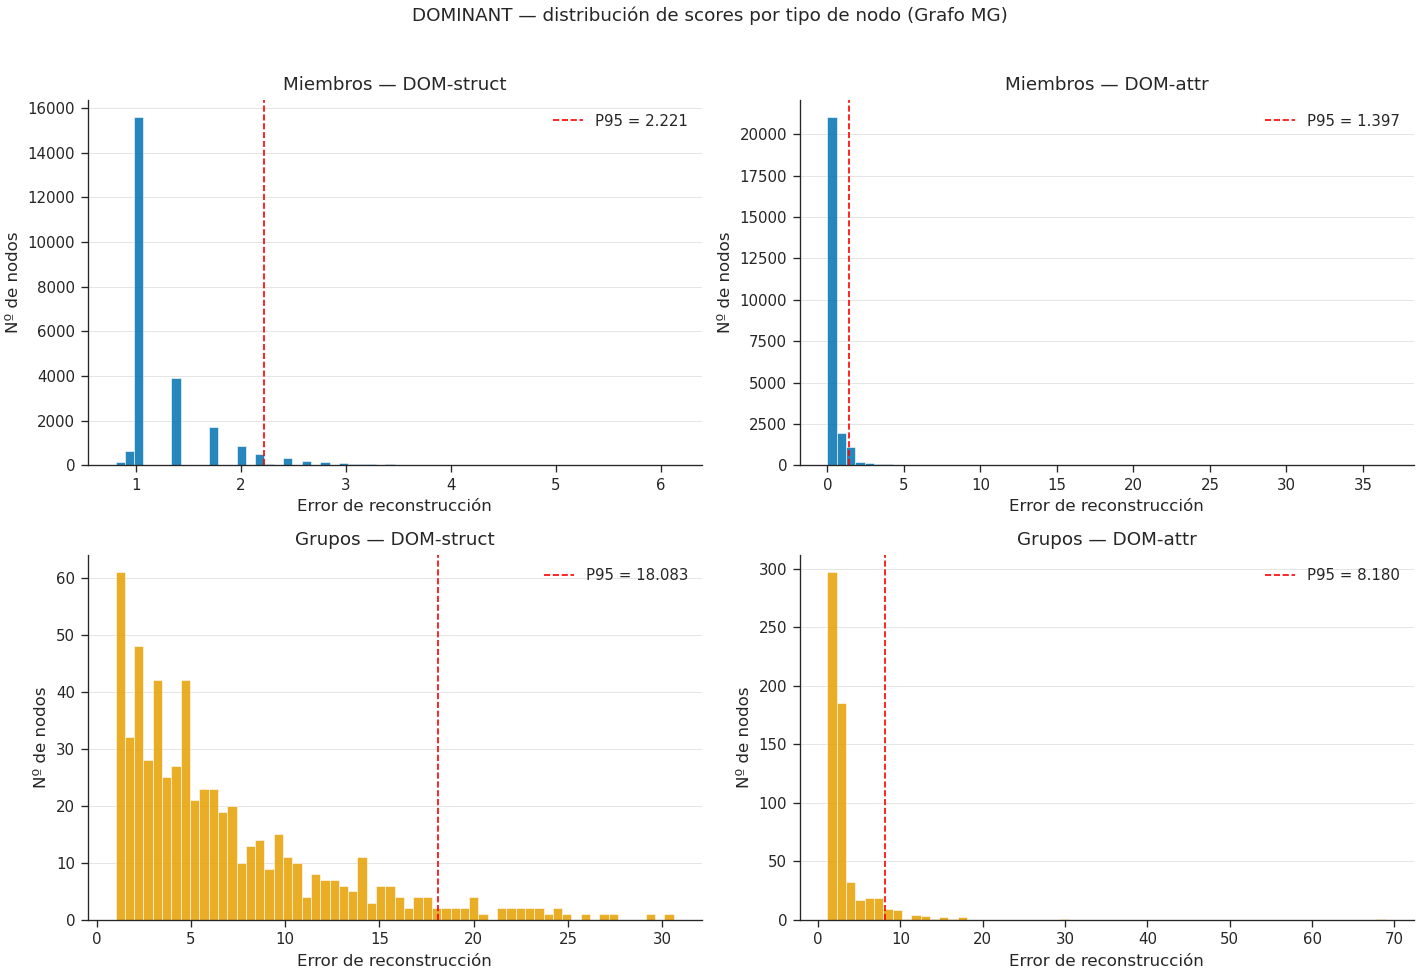


dom_struct:
  Miembros — mean=1.2589, median=0.9987, P95=2.2215
  Grupos   — mean=6.7194, median=4.9067, P95=18.0835

dom_attr:
  Miembros — mean=0.3193, median=0.0836, P95=1.3971
  Grupos   — mean=3.2364, median=2.2775, P95=8.1800


In [63]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.1 DOMINANT — distribución de scores por tipo de nodo
# ═══════════════════════════════════════════════════════════════════════════

# Separar scores por tipo de nodo
members_df = scores_df[scores_df['node_type'] == 'member'].copy()
groups_df  = scores_df[scores_df['node_type'] == 'group'].copy()

fig, axes = plt.subplots(2, 2, figsize=FS['r2c2'])

for row_ax, (df, tipo, color) in zip(axes, [
    (members_df, 'Miembros', PALETTE['M']),
    (groups_df,  'Grupos',   PALETTE['G'])
]):
    for ax, (col, label) in zip(row_ax, [
        ('dom_struct', 'DOM-struct'),
        ('dom_attr',   'DOM-attr')
    ]):
        ax.hist(df[col], bins=60, color=color, edgecolor='white', alpha=0.85)
        p95 = np.percentile(df[col], 95)
        ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
                   label=f'P95 = {p95:.3f}')
        ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
        ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
        ax.set_title(f'{tipo} — {label}', fontsize=FONT['title'])
        ax.legend(fontsize=FONT['legend'], frameon=False)
        polish(ax)

plt.suptitle('DOMINANT — distribución de scores por tipo de nodo (Grafo MG)',
             fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_dominant_scores_by_node_type_MG.png')
plt.show()

for col in ['dom_struct', 'dom_attr']:
    print(f'\n{col}:')
    print(f'  Miembros — mean={members_df[col].mean():.4f}, '
          f'median={members_df[col].median():.4f}, '
          f'P95={np.percentile(members_df[col], 95):.4f}')
    print(f'  Grupos   — mean={groups_df[col].mean():.4f}, '
          f'median={groups_df[col].median():.4f}, '
          f'P95={np.percentile(groups_df[col], 95):.4f}')

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_scores_by_node_type_MG.png


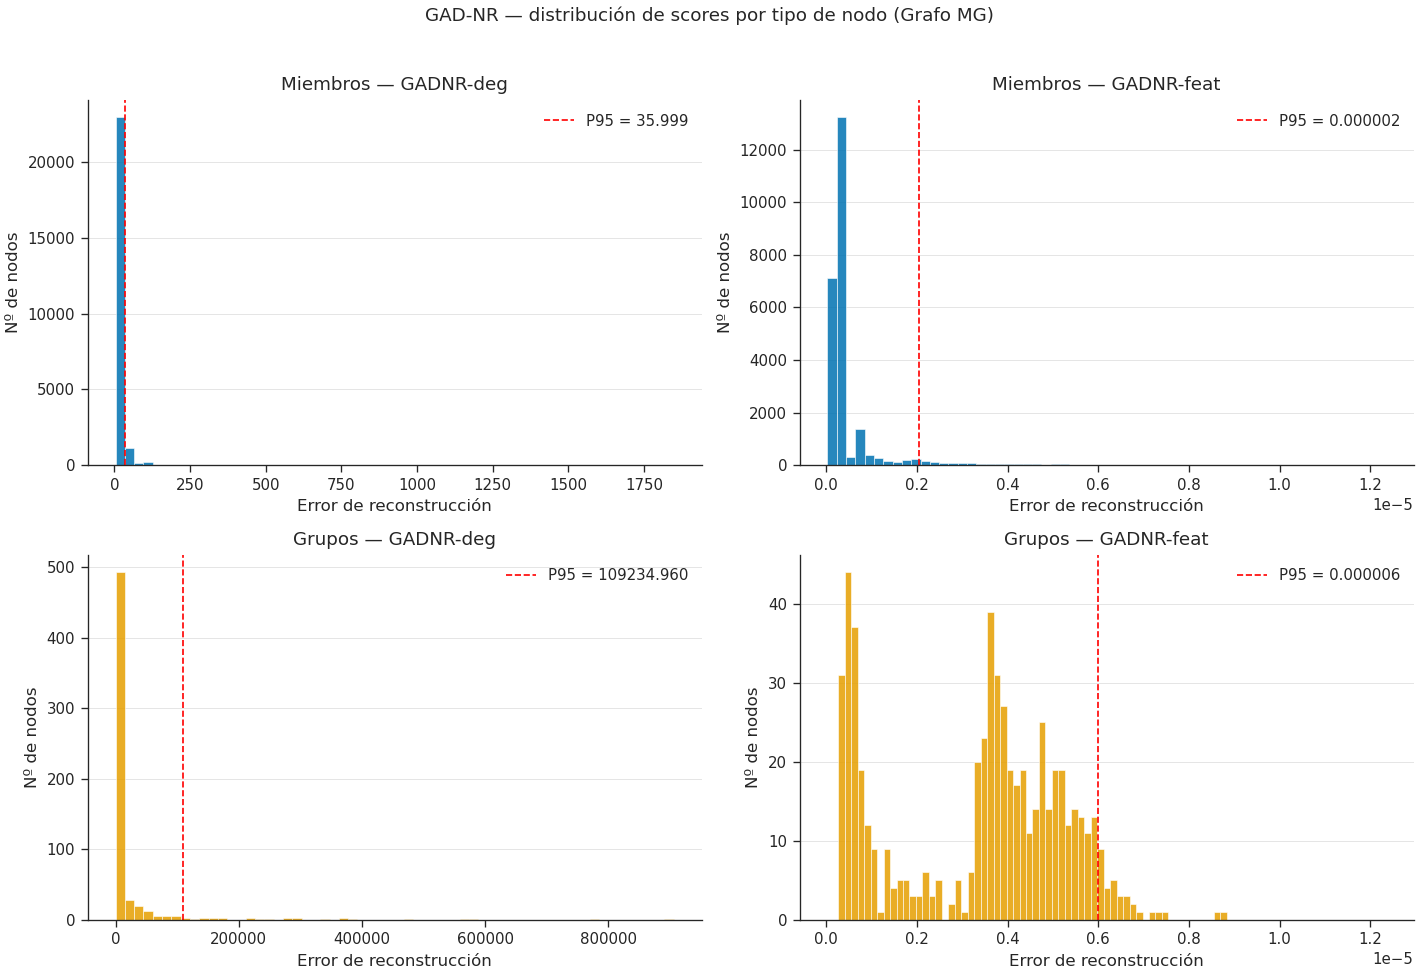


gadnr_deg:
  Miembros — mean=11.9182, median=3.9998, P95=35.9994
  Grupos   — mean=22328.7511, median=624.9975, P95=109234.9600

gadnr_feat:
  Miembros — mean=0.000000, median=0.000000, P95=0.000002
  Grupos   — mean=0.000003, median=0.000004, P95=0.000006


In [79]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.1 GAD-NR — distribución de scores por tipo de nodo
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=FS['r2c2'])

for row_ax, (df, tipo, color) in zip(axes, [
    (members_df, 'Miembros', PALETTE['M']),
    (groups_df,  'Grupos',   PALETTE['G'])
]):
    for j, (ax, (col, label)) in enumerate(zip(row_ax, [
        ('gadnr_deg',  'GADNR-deg'),
        ('gadnr_feat', 'GADNR-feat')
    ])):
        ax.hist(df[col], bins=60, color=color, edgecolor='white', alpha=0.85)
        p95 = np.percentile(df[col], 95)
        fmt = '.6f' if j == 1 else '.3f'
        ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
                   label=f'P95 = {p95:{fmt}}')
        ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
        ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
        ax.set_title(f'{tipo} — {label}', fontsize=FONT['title'])
        ax.legend(fontsize=FONT['legend'], frameon=False)
        polish(ax)
axes[1, 1].set_xlim(axes[0, 1].get_xlim())
plt.suptitle('GAD-NR — distribución de scores por tipo de nodo (Grafo MG)',
             fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '07_gadnr_scores_by_node_type_MG.png')
plt.show()

for col in ['gadnr_deg', 'gadnr_feat']:
    fmt = '.6f' if col == 'gadnr_feat' else '.4f'
    print(f'\n{col}:')
    print(f'  Miembros — mean={members_df[col].mean():{fmt}}, '
          f'median={members_df[col].median():{fmt}}, '
          f'P95={np.percentile(members_df[col], 95):{fmt}}')
    print(f'  Grupos   — mean={groups_df[col].mean():{fmt}}, '
          f'median={groups_df[col].median():{fmt}}, '
          f'P95={np.percentile(groups_df[col], 95):{fmt}}')

### 8.2 Cruce con perfiles de comportamiento de miembros

Distribución de perfiles en los 24.631 miembros del bipartito:

| Perfil | N | % |
|---|---|---|
| Normal | 13.444 | 54.6% |
| Inactivo | 10.834 | 44.0% |
| Fiel | 177 | 0.7% |
| Explorador | 151 | 0.6% |
| Hiperactivo | 25 | 0.1% |

**Fracción de anomalías detectadas (frac_P95) por perfil y señal:**

| Perfil | dom_struct | dom_attr | gadnr_deg | gadnr_feat | gadnr_h |
|---|---|---|---|---|---|
| **Explorador** | **1.000** | 0.252 | **1.000** | 0.729 | 0.000 |
| **Hiperactivo** | **0.560** | 0.200 | **0.840** | 0.480 | 0.000 |
| Normal | 0.079 | 0.073 | 0.113 | 0.082 | 0.037 |
| Inactivo | 0.000 | 0.019 | 0.000 | 0.000 | 0.067 |
| **Fiel** | 0.000 | 0.006 | 0.000 | 0.017 | 0.062 |

Los resultados son contundentes:

**Exploradores (151 miembros) — 100% detectados como anomalía estructural** por ambos modelos. Pertenecer a más de 10 grupos con baja asistencia produce un patrón de conectividad que el modelo no puede reconstruir bien. Son los miembros más claramente anómalos del grafo MG desde la perspectiva estructural.

**Hiperactivos (25 miembros) — 56-84% detectados** en señales estructurales. Un subconjunto como Matt Kenigson (34 grupos, 174 eventos, P99 en dom_struct) o Taylor Michael Matson (32 grupos, 201 eventos, P99 en dom_struct y gadnr_deg) coincide con los super-conectores del grafo M.

**Inactivos (10.834 miembros) — frac_P95 ≈ 0** en señales estructurales. Con grado 0 o 1 en el bipartito, estos miembros son invisibles para la señal estructural. Solo gadnr_h muestra una fracción marginal (6.7%), y como se documenta en 5.5, es un artefacto de nodos aislados.

**Fieles (177 miembros) — prácticamente no detectados** en ninguna señal. Alta asistencia concentrada en pocos grupos produce un patrón de conectividad perfectamente coherente para el modelo.


In [31]:
# Construir perfiles de comportamiento para los miembros del bipartito
# Basado en el EDA del grafo MG: total_events y num_groups por miembro

# Agregar información de actividad desde mg_edges
member_activity = mg_edges.groupby('member_id').agg(
    total_events=('weight', 'sum'),
    num_groups=('group_id', 'count'),
    mean_events_per_group=('weight', 'mean')
).reset_index()

# Definición de perfiles (del EDA)
def assign_profile(row):
    if row['total_events'] <= 1:
        return 'Inactivo'
    elif row['num_groups'] > 10 and row['mean_events_per_group'] < 3:
        return 'Explorador'
    elif row['num_groups'] <= 3 and row['mean_events_per_group'] > 30:
        return 'Fiel'
    elif row['total_events'] > 100:
        return 'Hiperactivo'
    else:
        return 'Normal'

member_activity['perfil'] = member_activity.apply(assign_profile, axis=1)

print('Distribución de perfiles:')
print(member_activity['perfil'].value_counts())

# Merge con scores_df para miembros
members_scores = members_df.merge(
    member_activity[['member_id', 'total_events', 'num_groups',
                     'mean_events_per_group', 'perfil']],
    left_on='raw_id', right_on='member_id', how='left'
)
members_scores['perfil'] = members_scores['perfil'].fillna('Normal')

print(f'\nMiembros con perfil asignado: {members_scores["perfil"].notna().sum()}')


Distribución de perfiles:
perfil
Normal         13444
Inactivo       10834
Fiel             177
Explorador       151
Hiperactivo       25
Name: count, dtype: int64

Miembros con perfil asignado: 24631


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_hist_profiles_MG.png


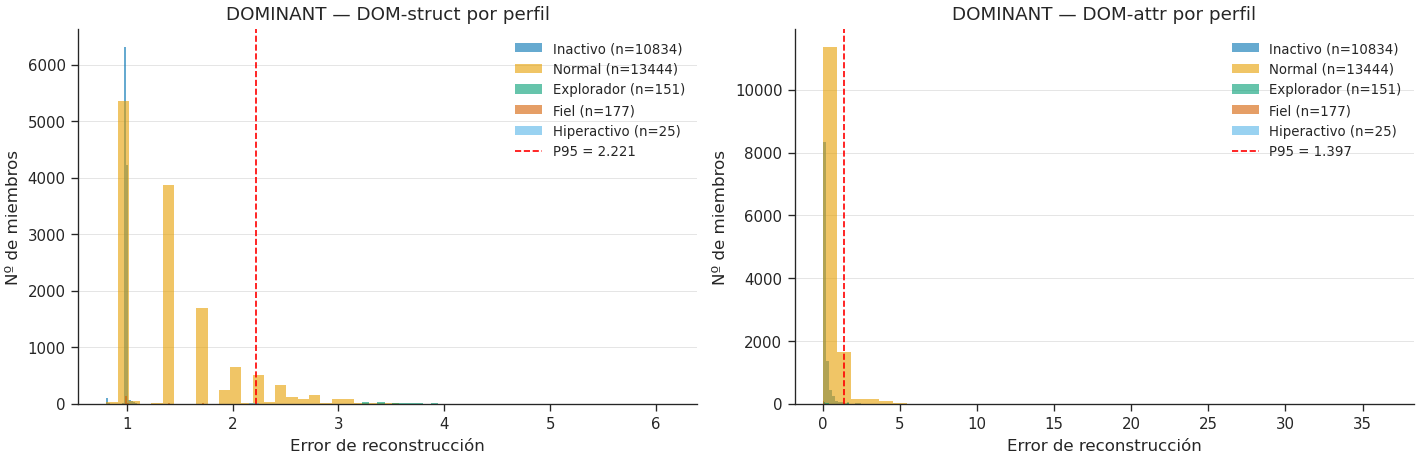

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_boxplot_profiles_MG.png


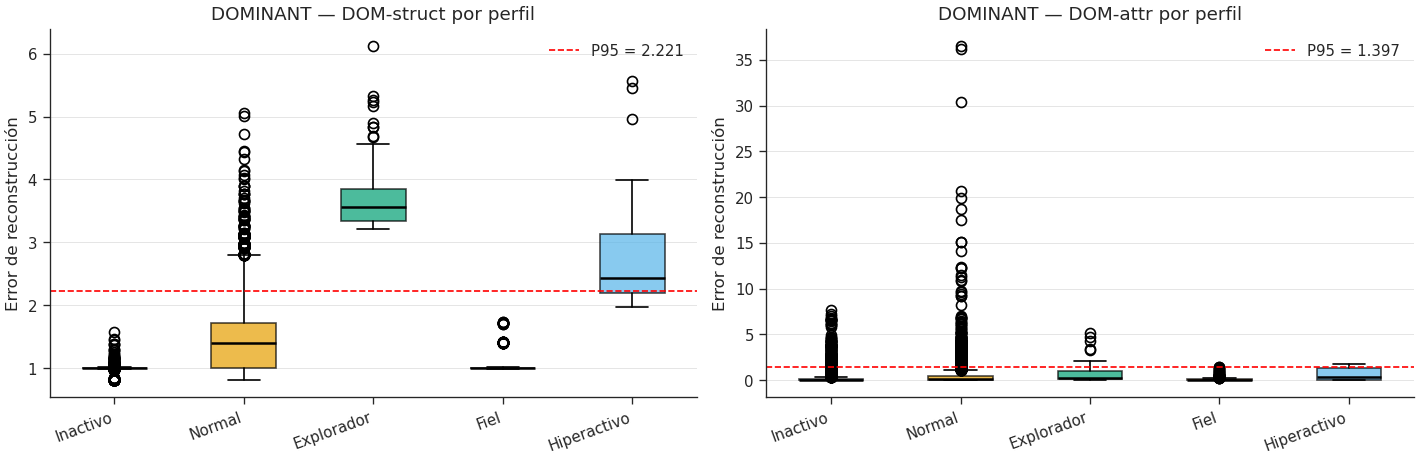

In [65]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 DOMINANT — perfiles de comportamiento
# ═══════════════════════════════════════════════════════════════════════════
perfil_order  = ['Inactivo', 'Normal', 'Explorador', 'Fiel', 'Hiperactivo']
perfil_colors = {p: CAT_COLORS[i] for i, p in enumerate(perfil_order)}

fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    for perfil in perfil_order:
        subset = members_scores[members_scores['perfil'] == perfil][col]
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.6,
                label=f'{perfil} (n={len(subset)})',
                color=perfil_colors[perfil], edgecolor='none')
    p95 = np.percentile(members_scores[col], 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de miembros', fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'] - 1, frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_dominant_hist_profiles_MG.png')
plt.show()

# Boxplot DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    data_by_perfil = [members_scores[members_scores['perfil'] == p][col].values
                      for p in perfil_order]
    bp = ax.boxplot(data_by_perfil, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, perfil in zip(bp['boxes'], perfil_order):
        patch.set_facecolor(perfil_colors[perfil])
        patch.set_alpha(0.7)
    p95 = np.percentile(members_scores[col], 95)
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xticklabels(perfil_order, rotation=20, ha='right',
                       fontsize=FONT['tick'])
    ax.set_ylabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_dominant_boxplot_profiles_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_hist_profiles_MG.png


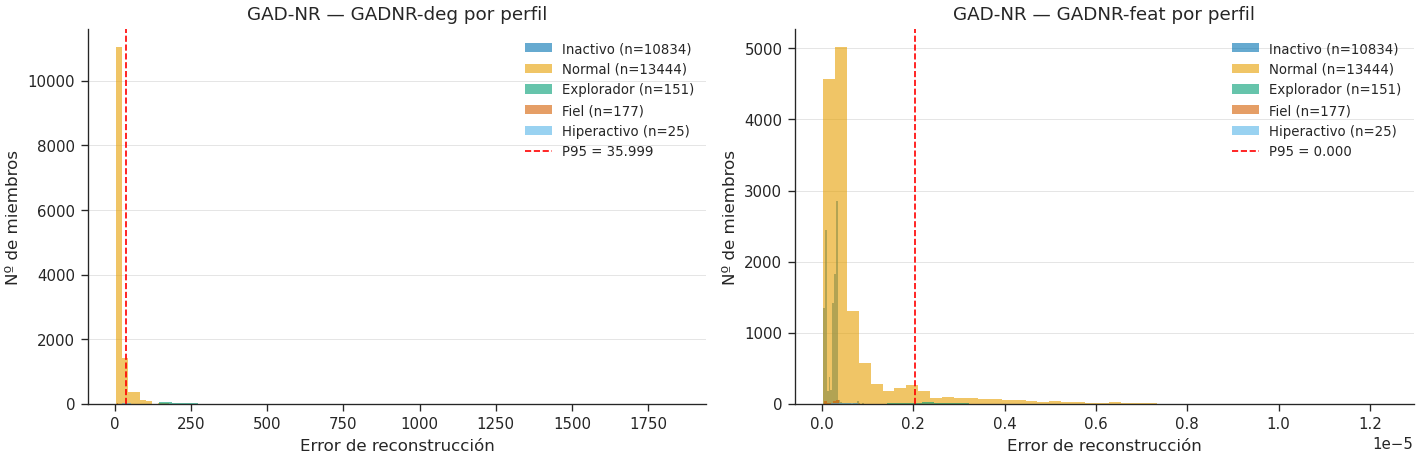

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_boxplot_profiles_MG.png


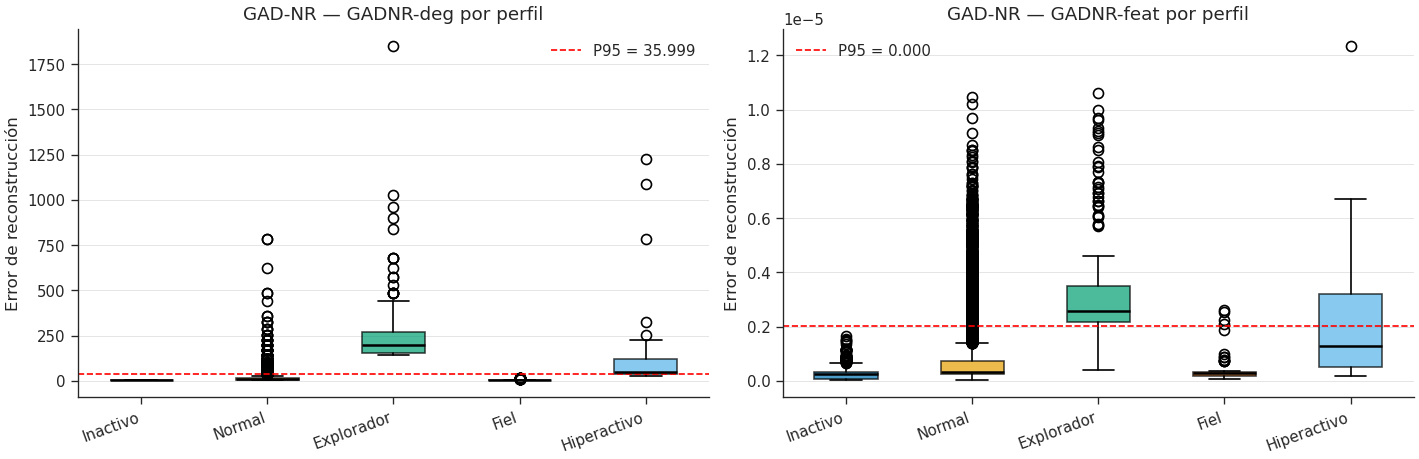

In [66]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 GAD-NR — perfiles de comportamiento
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    for perfil in perfil_order:
        subset = members_scores[members_scores['perfil'] == perfil][col]
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.6,
                label=f'{perfil} (n={len(subset)})',
                color=perfil_colors[perfil], edgecolor='none')
    p95 = np.percentile(members_scores[col], 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de miembros', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'] - 1, frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_hist_profiles_MG.png')
plt.show()

# Boxplot GAD-NR
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat']):
    data_by_perfil = [members_scores[members_scores['perfil'] == p][col].values
                      for p in perfil_order]
    bp = ax.boxplot(data_by_perfil, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, perfil in zip(bp['boxes'], perfil_order):
        patch.set_facecolor(perfil_colors[perfil])
        patch.set_alpha(0.7)
    p95 = np.percentile(members_scores[col], 95)
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xticklabels(perfil_order, rotation=20, ha='right',
                       fontsize=FONT['tick'])
    ax.set_ylabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} por perfil', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '07_gadnr_boxplot_profiles_MG.png')
plt.show()

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2 Tabla estadísticos por perfil — cinco señales
# ═══════════════════════════════════════════════════════════════════════════
score_cols_members = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']

for col in score_cols_members:
    p95_global = np.percentile(members_scores[col], 95)
    print(f'\n=== {col} — frac_P95 por perfil ===')
    print(members_scores.groupby('perfil')[col].agg(
        mean='mean',
        median='median',
        std='std',
        frac_P95=lambda x: (x >= p95_global).mean()
    ).round(4).to_string())


=== dom_struct — frac_P95 por perfil ===
               mean  median     std  frac_P95
perfil                                       
Explorador   3.7085  3.5686  0.5179    1.0000
Fiel         1.0885  0.9962  0.2096    0.0000
Hiperactivo  2.9179  2.4353  1.0785    0.5600
Inactivo     0.9951  0.9963  0.0244    0.0000
Normal       1.4431  1.4036  0.5077    0.0794

=== dom_attr — frac_P95 por perfil ===
               mean  median     std  frac_P95
perfil                                       
Explorador   0.6371  0.2034  0.9323    0.2450
Fiel         0.1683  0.0498  0.2794    0.0056
Hiperactivo  0.5885  0.3061  0.6410    0.2000
Inactivo     0.1864  0.0454  0.4633    0.0214
Normal       0.4244  0.1068  0.9760    0.0712

=== gadnr_deg — frac_P95 por perfil ===
                   mean      median         std  frac_P95
perfil                                                   
Explorador   270.124298  195.998596  209.352798    1.0000
Fiel           5.338800    3.999800    3.190500    0.0000
H

In [84]:
# ─────────────────────────────────────────────────────────────────────────────
# Resumen ejecutivo: fracción P95 por perfil y señal
# ─────────────────────────────────────────────────────────────────────────────

perfil_order = ['Inactivo', 'Normal', 'Explorador', 'Fiel', 'Hiperactivo']
cols_pct = ['pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

rows = []
for perfil in perfil_order:
    sub = members_scores[members_scores['perfil'] == perfil]
    row = {'Perfil': perfil, 'N': len(sub)}
    for col in cols_pct:
        n_out = (sub[col] >= P_THRESH).sum()
        row[col.replace('pct_', '')] = f"{100*n_out/len(sub):.1f}%"
    rows.append(row)

print("=== Fracción de nodos P95 por perfil de comportamiento ===")
print(pd.DataFrame(rows).to_string(index=False))

=== Fracción de nodos P95 por perfil de comportamiento ===
     Perfil     N dom_struct dom_attr gadnr_deg gadnr_feat gadnr_h
   Inactivo 10834       0.0%     1.6%      0.0%       0.0%    6.8%
     Normal 13444       4.6%     3.9%      4.5%       5.8%    3.8%
 Explorador   151     100.0%    19.2%    100.0%      45.7%    0.0%
       Fiel   177       0.0%     0.0%      0.0%       0.0%    6.2%
Hiperactivo    25      48.0%    12.0%     48.0%      44.0%    0.0%


### 8.3 Cruce con ratio de actividad de grupos

Distribución de grupos por categoría de actividad (602 grupos totales):

| Categoría | N | % |
|---|---|---|
| Bajo (10-25%) | 235 | 39.0% |
| Normal (>25%) | 141 | 23.4% |
| Muy bajo (5-10%) | 115 | 19.1% |
| Fantasma (<5%) | 111 | 18.4% |

**Fracción de anomalías (frac_P95) por categoría y señal:**

| Categoría | dom_struct | dom_attr | gadnr_deg | gadnr_feat | gadnr_h |
|---|---|---|---|---|---|
| Normal (>25%) | **0.099** | **0.085** | **0.099** | 0.043 | **0.092** |
| Bajo (10-25%) | 0.064 | 0.064 | 0.064 | 0.055 | 0.047 |
| Muy bajo (5-10%) | 0.017 | 0.009 | 0.017 | 0.052 | 0.044 |
| **Fantasma (<5%)** | **0.000** | 0.027 | **0.000** | 0.054 | 0.027 |

El resultado más contraintuitivo: **los grupos fantasma (ratio < 5%) tienen frac_P95 = 0 en la señal estructural**. Tener ratio de actividad bajo implica tener pocos miembros activos en el bipartito y por tanto un grado bajo — y los nodos de grado bajo son estructuralmente fáciles de reconstruir para el modelo, no anómalos.

En cambio, **los grupos Normal (ratio > 25%) son los más detectados** en ambas señales estructurales. Son grupos con muchos miembros activos → grado alto en el bipartito → patrón de conectividad difícil de reconstruir.

La única señal donde los fantasmas tienen presencia comparable es `dom_attr` (frac_P95 = 0.027), coherente con el hallazgo del spotlight: Nashville Social Crew y similares tienen features (log_num_members alto, active_members bajo) que el decoder de atributos penaliza.

**Nota:** 0 grupos truncados a 200 eventos en este grafo — el truncamiento identificado en el EDA afecta a `meta_events` pero no se propaga al bipartito de la misma forma.


In [35]:
# Ratio de actividad: miembros activos en bipartito / miembros registrados en meta_groups
active_per_group = mg_edges.groupby('group_id').size().reset_index(name='active_members')
meta_groups_activity = meta_groups[['group_id', 'group_name', 'num_members', 'category_name']].merge(
    active_per_group, on='group_id', how='left'
)
meta_groups_activity['active_members'] = meta_groups_activity['active_members'].fillna(0)
meta_groups_activity['activity_ratio'] = (
    meta_groups_activity['active_members'] / meta_groups_activity['num_members']
)

# Categorías de ratio de actividad
def assign_activity_cat(ratio):
    if ratio < 0.05:  return 'Fantasma (<5%)'
    elif ratio < 0.10: return 'Muy bajo (5-10%)'
    elif ratio < 0.25: return 'Bajo (10-25%)'
    else:              return 'Normal (>25%)'

meta_groups_activity['activity_cat'] = meta_groups_activity['activity_ratio'].apply(assign_activity_cat)

print('Distribución de categorías de actividad:')
print(meta_groups_activity['activity_cat'].value_counts())
print(f'\nGrupos truncados (200 eventos): {(meta_groups_activity.get("num_events", pd.Series()) == 200).sum()}')

# Merge con scores_df para grupos
groups_scores = groups_df.merge(
    meta_groups_activity[['group_id', 'activity_ratio', 'activity_cat', 'active_members']],
    left_on='raw_id', right_on='group_id', how='left'
)

print(f'\nGrupos con ratio asignado: {groups_scores["activity_ratio"].notna().sum()}')


Distribución de categorías de actividad:
activity_cat
Bajo (10-25%)       235
Normal (>25%)       141
Muy bajo (5-10%)    115
Fantasma (<5%)      111
Name: count, dtype: int64

Grupos truncados (200 eventos): 0

Grupos con ratio asignado: 602


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_activity_ratio_MG.png


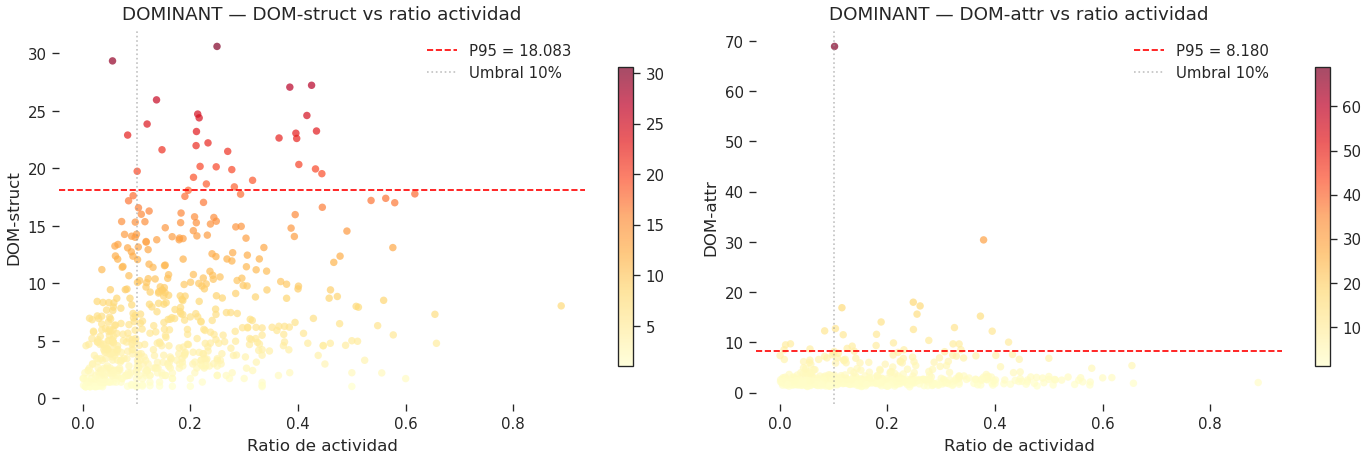

In [80]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 DOMINANT — ratio de actividad de grupos
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    sc = ax.scatter(
        groups_scores['activity_ratio'],
        groups_scores[col],
        c=groups_scores[col],
        s=20, alpha=0.7, cmap=CMAP_HEAT, edgecolors='none'
    )
    p95 = np.percentile(groups_scores[col], 95)
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.axvline(0.10, color=PALETTE['neutral'], linestyle=':', linewidth=1.0,
               alpha=0.6, label='Umbral 10%')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel('Ratio de actividad', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} vs ratio actividad', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_dominant_activity_ratio_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_activity_ratio_MG.png


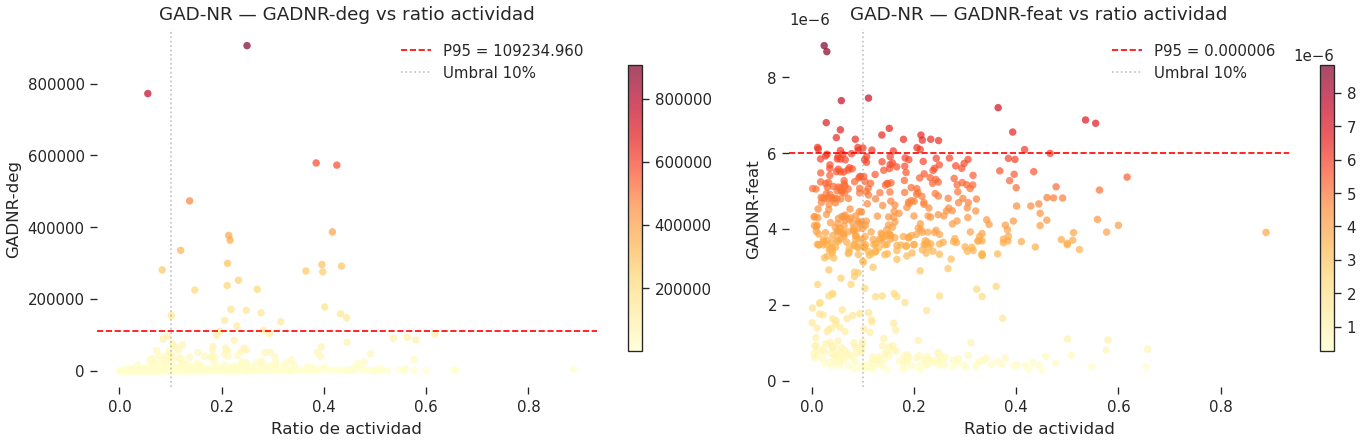

In [83]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 GAD-NR — ratio de actividad de grupos
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for i, (ax, col, label) in enumerate(zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat'])):
    sc = ax.scatter(
        groups_scores['activity_ratio'],
        groups_scores[col],
        c=groups_scores[col],
        s=20, alpha=0.7, cmap=CMAP_HEAT, edgecolors='none'
    )
    p95 = np.percentile(groups_scores[col], 95)
    fmt = '.6f' if i == 1 else '.3f'
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:{fmt}}')
    ax.axvline(0.10, color=PALETTE['neutral'], linestyle=':', linewidth=1.0,
               alpha=0.6, label='Umbral 10%')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel('Ratio de actividad', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} vs ratio actividad', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_gadnr_activity_ratio_MG.png')
plt.show()

In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3 Tabla estadísticos por categoría de actividad — cinco señales
# ═══════════════════════════════════════════════════════════════════════════
score_cols_groups = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']

for col in score_cols_groups:
    p95_global = np.percentile(groups_scores[col], 95)
    print(f'\n=== {col} por categoría de actividad ===')
    print(groups_scores.groupby('activity_cat')[col].agg(
        count='count',
        mean='mean',
        median='median',
        frac_P95=lambda x: (x >= p95_global).mean()
    ).round(4).to_string())


=== dom_struct por categoría de actividad ===
                  count    mean  median  frac_P95
activity_cat                                     
Bajo (10-25%)       235  7.5862  6.0015    0.0638
Fantasma (<5%)      111  3.2188  2.4169    0.0000
Muy bajo (5-10%)    115  6.0082  4.6952    0.0174
Normal (>25%)       141  8.6106  6.2744    0.0993

=== dom_attr por categoría de actividad ===
                  count    mean  median  frac_P95
activity_cat                                     
Bajo (10-25%)       235  3.5364  2.3151    0.0638
Fantasma (<5%)      111  2.4945  2.0435    0.0270
Muy bajo (5-10%)    115  2.6340  2.1188    0.0174
Normal (>25%)       141  3.8116  2.5717    0.0780

=== gadnr_deg por categoría de actividad ===
                  count          mean       median  frac_P95
activity_cat                                                
Bajo (10-25%)       235  27112.826172  1368.996338    0.0638
Fantasma (<5%)      111    654.512024    48.999298    0.0000
Muy bajo (5-10%)  

In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# Resumen ejecutivo: fracción P95 por categoría de actividad
# ─────────────────────────────────────────────────────────────────────────────

cat_order = ['Normal (>25%)', 'Bajo (10-25%)', 'Muy bajo (5-10%)', 'Fantasma (<5%)']
cols_pct  = ['pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

rows = []
for cat in cat_order:
    sub = groups_scores[groups_scores['activity_cat'] == cat]
    row = {'Categoría': cat, 'N': len(sub)}
    for col in cols_pct:
        n_out = (sub[col] >= P_THRESH).sum()
        row[col.replace('pct_', '')] = f"{100*n_out/len(sub):.1f}%"
    rows.append(row)

print("=== Fracción de grupos P95 por categoría de actividad ===")
print(pd.DataFrame(rows).to_string(index=False))
print()

# Casos representativos de grupos fantasma
print("=== Top-5 grupos fantasma por dom_attr ===")
fantasma = groups_scores[groups_scores['activity_cat'] == 'Fantasma (<5%)']
cols_show = ['name', 'activity_ratio', 'active_members',
             'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat']
print(fantasma[cols_show].sort_values('pct_dom_attr', ascending=False)
      .head(5).to_string(index=False))

=== Fracción de grupos P95 por categoría de actividad ===
       Categoría   N dom_struct dom_attr gadnr_deg gadnr_feat gadnr_h
   Normal (>25%) 141      88.7%    90.1%     88.7%      68.8%    0.0%
   Bajo (10-25%) 235      86.8%    90.6%     85.1%      66.0%    0.0%
Muy bajo (5-10%) 115      78.3%    81.7%     72.2%      73.0%    0.0%
  Fantasma (<5%) 111      49.5%    89.2%     47.7%      63.1%    0.0%

=== Top-5 grupos fantasma por dom_attr ===
                                                   name  activity_ratio  active_members  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat
                        MHO Nashville Active Adventures        0.020047              34       98.977529     99.857330      98.973566       81.801609
                Nashville Tennis Lessons- PlayYourCourt        0.010989               2       76.831926     99.841477      73.031348       96.667063
                                Nashville Travel Meetup        0.008108               3       83.7871

### 8.4 Análisis de pesos de aristas

El peso de arista en MG es la única métrica de **actividad real** del dataset: número de eventos asistidos por el miembro en ese grupo.

**Estadísticas de peso medio por nodo:**
- Miembros: media 2.76, mediana 1.00, máximo 200.0
- Grupos: media 2.69, mediana 2.00, máximo 41.79

El máximo de 200 en miembros corresponde al truncamiento de la API de Meetup (identificado en el EDA de `meta_events`): miembros con más de 200 asistencias registradas en un grupo quedan limitados a ese valor.

**Correlación Spearman entre peso medio y señales de anomalía (miembros):**

| Señal | ρ |
|---|---|
| `gadnr_deg` | **0.284** |
| `dom_struct` | 0.205 |
| `gadnr_feat` | 0.181 |
| `dom_attr` | 0.082 |
| `gadnr_h` | 0.063 |

Todas las correlaciones son **positivas y moderadas**: los miembros con mayor actividad real (más eventos asistidos de media) tienden a tener scores de anomalía más altos. La lógica es directa — un miembro que asiste a muchos eventos en muchos grupos tiene un grado alto en el bipartito, y los nodos de alto grado son estructuralmente difíciles de reconstruir.

La señal más correlacionada con la actividad real es `gadnr_deg` (ρ = 0.284), seguida de `dom_struct` (ρ = 0.205). Las señales de atributo tienen correlaciones mucho menores, lo que confirma que la información de actividad real está codificada principalmente en la estructura del grafo, no en las features.


In [39]:
# El peso de arista en MG = número de eventos asistidos
# Es la única métrica de actividad real del dataset

# Peso medio de aristas por nodo
edge_src_np  = data_MG.edge_index[0].numpy()
edge_dst_np  = data_MG.edge_index[1].numpy()
edge_weights = data_MG.edge_weight.numpy()

# Peso medio por nodo (promedio de los pesos de todas sus aristas)
weight_sum   = np.bincount(edge_src_np, weights=edge_weights, minlength=data_MG.num_nodes)
degree_count = np.bincount(edge_src_np, minlength=data_MG.num_nodes)
mean_weight  = np.where(degree_count > 0, weight_sum / degree_count, 0)

scores_df['mean_edge_weight'] = mean_weight

# Para miembros: peso medio = media de eventos por grupo
# Para grupos: peso medio = media de eventos por miembro activo
print('Peso medio de aristas:')
print(f'  Miembros — mean={mean_weight[:n_members].mean():.2f}, '
      f'median={np.median(mean_weight[:n_members]):.2f}, '
      f'max={mean_weight[:n_members].max():.2f}')
print(f'  Grupos   — mean={mean_weight[n_members:].mean():.2f}, '
      f'median={np.median(mean_weight[n_members:]):.2f}, '
      f'max={mean_weight[n_members:].max():.2f}')


Peso medio de aristas:
  Miembros — mean=2.76, median=1.00, max=200.00
  Grupos   — mean=2.69, median=2.00, max=41.79


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_weight_vs_score_MG.png


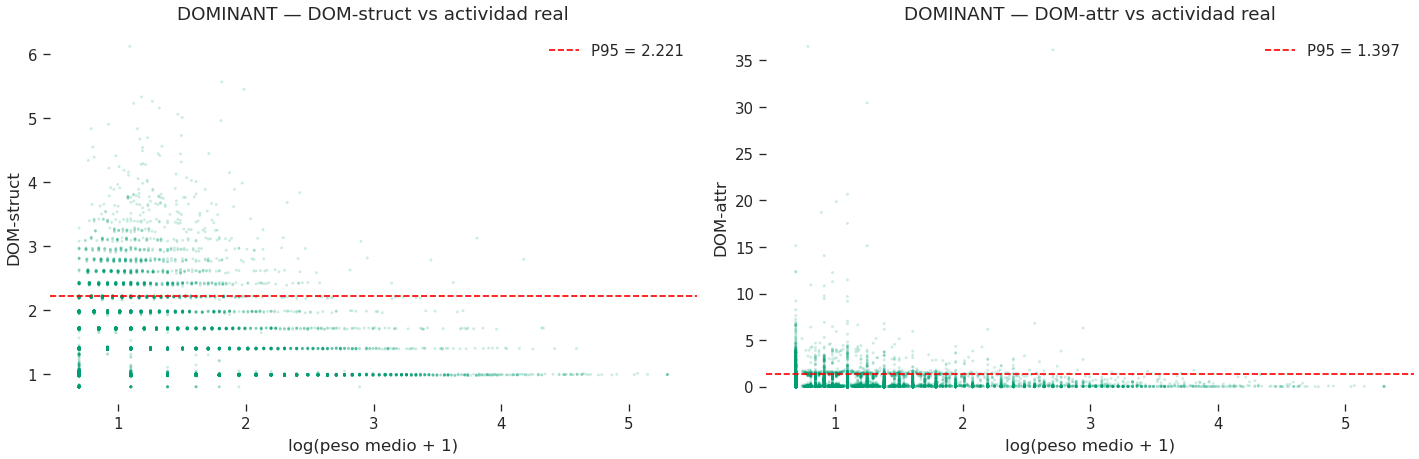

In [71]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 DOMINANT — peso de aristas vs score
# ═══════════════════════════════════════════════════════════════════════════
member_weights = mean_weight[:n_members]

fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for ax, col, label in zip(axes,
                           ['dom_struct', 'dom_attr'],
                           ['DOM-struct', 'DOM-attr']):
    ax.scatter(np.log1p(member_weights),
               members_df[col],
               s=3, alpha=0.2, color=PALETTE['MG'], edgecolors='none')
    p95 = np.percentile(members_df[col], 95)
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('log(peso medio + 1)', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'DOMINANT — {label} vs actividad real', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_dominant_weight_vs_score_MG.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_weight_vs_score_MG.png


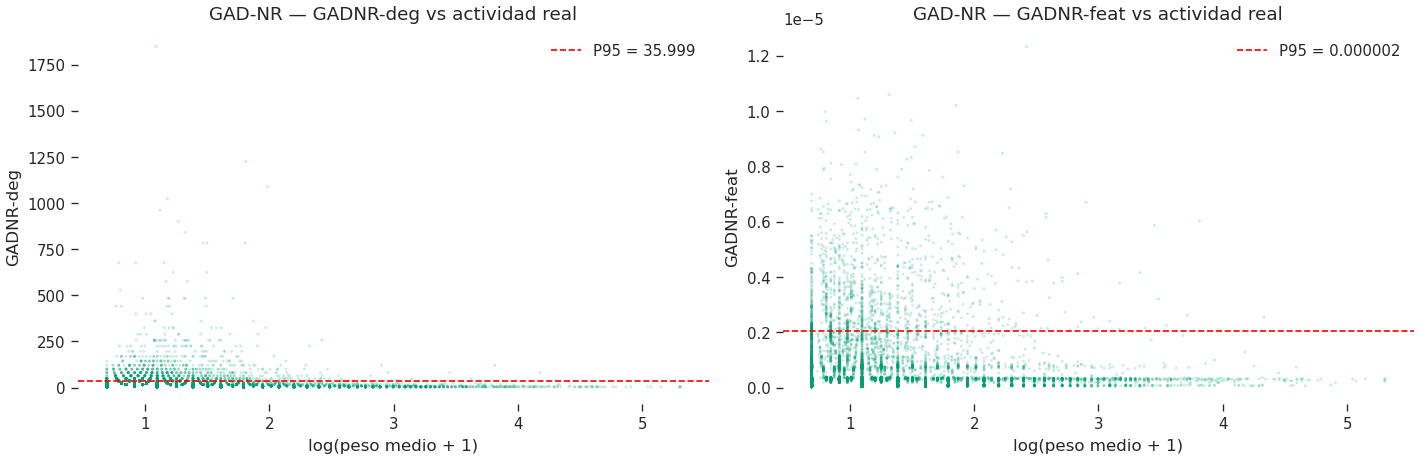

In [82]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 GAD-NR — peso de aristas vs score
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])
for i, (ax, col, label) in enumerate(zip(axes,
                           ['gadnr_deg', 'gadnr_feat'],
                           ['GADNR-deg', 'GADNR-feat'])):
    ax.scatter(np.log1p(member_weights),
               members_df[col],
               s=3, alpha=0.2, color=PALETTE['MG'], edgecolors='none')
    p95 = np.percentile(members_df[col], 95)
    fmt = '.6f' if i == 1 else '.3f'
    ax.axhline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:{fmt}}')
    ax.set_xlabel('log(peso medio + 1)', fontsize=FONT['axis_label'])
    ax.set_ylabel(label, fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label} vs actividad real', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '07_gadnr_weight_vs_score_MG.png')
plt.show()

In [42]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4 Correlaciones peso medio vs cinco señales
# ═══════════════════════════════════════════════════════════════════════════
print('Correlación Spearman peso_medio vs señales (miembros):')
for col in ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']:
    rho, _ = spearmanr(member_weights, members_df[col])
    print(f'  {col:<15}: ρ = {rho:.4f}')

Correlación Spearman peso_medio vs señales (miembros):
  dom_struct     : ρ = 0.2038
  dom_attr       : ρ = 0.0888
  gadnr_deg      : ρ = 0.2840
  gadnr_feat     : ρ = 0.1850
  gadnr_h        : ρ = 0.0601


### 8.5 Spotlight por perfil de comportamiento

**Exploradores — top anomalías estructurales:**

Los top-3 exploradores por dom_combined son miembros con 12-19 grupos y 15-35 eventos totales, residentes fuera de Nashville (Bangor, Toronto, Marietta) o en ciudades satélite. Todos superan el P97 en dom_struct y gadnr_deg simultáneamente. El caso más extremo es Cesar G. (19 grupos, P98.5 estructural en ambos modelos).

**Hiperactivos — perfil dividido:**

Matt Kenigson y Taylor Michael Matson lideran por dom_combined (P99 en ambas señales estructurales), confirmando su doble rol de hiperactivos + exploradores. Robin Barnes (442 eventos en 10 grupos) representa el perfil fiel-hiperactivo: P97 estructural pero con la actividad muy concentrada.

**Inactivos — anomalías de atributo, no estructurales:**

Los top-3 inactivos por dom_combined tienen grado 0 y una única asistencia, pero alcanzan el P99 en dom_attr. El patrón es consistente: miembros internacionales (Hafnarfjörður, Anchorage, Rio de Janeiro) cuyas features geográficas son extremas en el contexto de una red fundamentalmente de Nashville.

**Grupos fantasma — detectados por atributo, invisibles para estructura:**

Los 5 grupos fantasma con mayor dom_attr incluyen Nashville Travel Meetup (ratio 0.8%, 3 miembros activos), Nashville Tennis Lessons (ratio 1.1%, 2 activos) e I am Happy Project (ratio 0.9%, 2 activos). Todos tienen scores de atributo en el P99 pero scores estructurales moderados (P71–P99). Nashville Social Crew (ratio 0.07%, el fantasma más extremo del EDA) alcanza P99.5 en dom_attr — detectado correctamente por la señal de atributo.

Por gadnr_deg, los grupos fantasma más detectados son Middle Tennessee Sierra Club y Nashville Socials and Events! — grupos con más miembros activos dentro del segmento fantasma (125 y 71 respectivamente), lo que les da grado suficiente para ser estructuralmente anómalos.


In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Spotlight por perfil — ordenado por dom_combined
# ═══════════════════════════════════════════════════════════════════════════
cols_show = ['name', 'city', 'degree', 'total_events', 'num_groups',
             'pct_dom_struct', 'pct_dom_attr',
             'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

print('=' * 70)
print('SPOTLIGHT POR PERFIL — ordenado por dom_combined')
print('=' * 70)
for perfil in perfil_order:
    subset = members_scores[members_scores['perfil'] == perfil]
    if len(subset) == 0:
        continue
    print(f'\n--- {perfil} (n={len(subset)}) ---')
    print(subset.nlargest(3, 'dom_combined')[cols_show].to_string(index=False))

SPOTLIGHT POR PERFIL — ordenado por dom_combined

--- Inactivo (n=10834) ---
         name          city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
Caroline Jacq     Melbourne       0             1           1       80.814806     99.770142      32.616019       88.447668    58.803947
  Jon Jonsson Hafnarfjörður       0             1           1       65.121072     99.738438      32.616019       44.065311    61.589981
      Janetta     Anchorage       0             1           1       65.184481     99.718622      32.616019       78.940277    63.109817

--- Normal (n=13444) ---
             name       city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
  Taplino Dahmari   Brisbane       2             6           5       92.660405     99.996037      92.474141       25.989775    58.887172
         Adrianne Wellington       1            28           2       80.691951 

In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Spotlight por perfil — ordenado por gadnr_score
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('SPOTLIGHT POR PERFIL — ordenado por gadnr_score')
print('=' * 70)
for perfil in perfil_order:
    subset = members_scores[members_scores['perfil'] == perfil]
    if len(subset) == 0:
        continue
    print(f'\n--- {perfil} (n={len(subset)}) ---')
    print(subset.nlargest(3, 'gadnr_score')[cols_show].to_string(index=False))

SPOTLIGHT POR PERFIL — ordenado por gadnr_score

--- Inactivo (n=10834) ---
       name       city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
Dean Dunfee  La Vergne       0             1           1       65.138905     93.048785      32.616019       91.828162    88.271311
     Amanda   Fairview       0             1           1       64.988309     92.287877      32.616019       91.483375    79.917172
 Pete Rolaf Chesapeake       0             1           1       65.146832     99.044902      32.616019       91.154441    67.126382

--- Normal (n=13444) ---
                name      city  degree  total_events  num_groups  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
      Samuel Danache Hermitage       5            19          10       97.467602     95.426624      97.342765       99.992074    87.627313
           Calvin J.   Antioch      12            83          24       98.688226     94.994650  

In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.5 Grupos fantasma — DOMINANT vs GAD-NR
# ═══════════════════════════════════════════════════════════════════════════
cols_groups_show = ['name', 'activity_ratio', 'active_members',
                    'pct_dom_struct', 'pct_dom_attr',
                    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']

fantasma = groups_scores[groups_scores['activity_cat'] == 'Fantasma (<5%)']
print(f'Total grupos fantasma: {len(fantasma)}')

print('\n--- Top-5 por dom_attr ---')
print(fantasma.nlargest(5, 'dom_attr')[cols_groups_show].to_string(index=False))

print('\n--- Top-5 por gadnr_deg ---')
print(fantasma.nlargest(5, 'gadnr_deg')[cols_groups_show].to_string(index=False))

Total grupos fantasma: 111

--- Top-5 por dom_attr ---
                                                   name  activity_ratio  active_members  pct_dom_struct  pct_dom_attr  pct_gadnr_deg  pct_gadnr_feat  pct_gadnr_h
                        MHO Nashville Active Adventures        0.020047              34       98.977529     99.857330      98.973566       81.801609    59.465779
                Nashville Tennis Lessons- PlayYourCourt        0.010989               2       76.831926     99.841477      73.031348       96.667063    59.889827
                                Nashville Travel Meetup        0.008108               3       83.787104     99.805810      84.262672       90.092339    60.805295
Nashville Social Crew! Dine, Hike, Photography, & More!        0.000747               3       87.690722     99.746364      84.262672       91.416003    60.250466
                     I am Happy Project - Brentwood, TN        0.008658               2       80.794991     99.635398      73.031348   

## 9. Visualización t-SNE de los embeddings

Proyectamos los embeddings latentes de cada modelo (dimensión 64) a 2D mediante t-SNE
(perplexity=30, init='pca', max_iter=1000, random_state=42). Con 25.233 nodos el cálculo
se realizó en GPU. Se generan cinco vistas por modelo.

**Resultados de DOMINANT:**

La vista por **tipo de nodo** muestra que los 602 grupos (puntos grandes, color ámbar) forman un cluster compacto y perfectamente separado del mar de miembros. El encoder GCN ha aprendido representaciones distintas para los dos tipos de nodo a pesar de no recibir esa información explícitamente — la heterogeneidad de features (3 vs 35 dimensiones con zero-padding diferente) es suficiente para que el espacio latente se organice por tipo.

La vista por **tipo de anomalía** muestra que los nodos Mixtos (rojo) se concentran mayoritariamente en el cluster de grupos, consistente con el crosstab de la sección 8.1 (79% de los Mixtos son grupos). Los Estructurales (azul) aparecen dispersos entre los grupos de mayor grado. Los Atributo (naranja) se mezclan con los miembros normales.

La vista por **perfil de comportamiento** es la más informativa del notebook: los Exploradores e Hiperactivos se concentran en zonas del espacio latente distintas de los Inactivos, confirmando que el embedding captura diferencias de comportamiento aunque solo haya visto la estructura del grafo.

**Resultados de GAD-NR:**

La vista por **tipo de nodo** también separa grupos de miembros, aunque con menor claridad que DOMINANT. El cluster de grupos es más difuso y algunos se mezclan con la periferia de los miembros.

Las vistas por **tipo de anomalía** y **score compuesto** muestran una distribución más dispersa que DOMINANT, sin clusters claramente definidos por tipología. Consistente con el comportamiento del curriculum: el embedding de GAD-NR en MG está organizado principalmente por `gadnr_deg`, no por el patrón global de anomalías.

La vista por **grado** confirma en ambos modelos que los grupos (mayor grado) se sitúan en zonas diferenciadas del espacio latente, con un gradiente continuo de grado visible.


In [46]:
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()

@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()

emb_dom   = get_dominant_embeddings(dominant, data_MG_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_MG_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (25233, 64)
Embeddings GAD-NR   : (25233, 64)


In [47]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)

tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (25233, 2)
t-SNE GAD-NR  shape: (25233, 2)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_node_type_MG.png


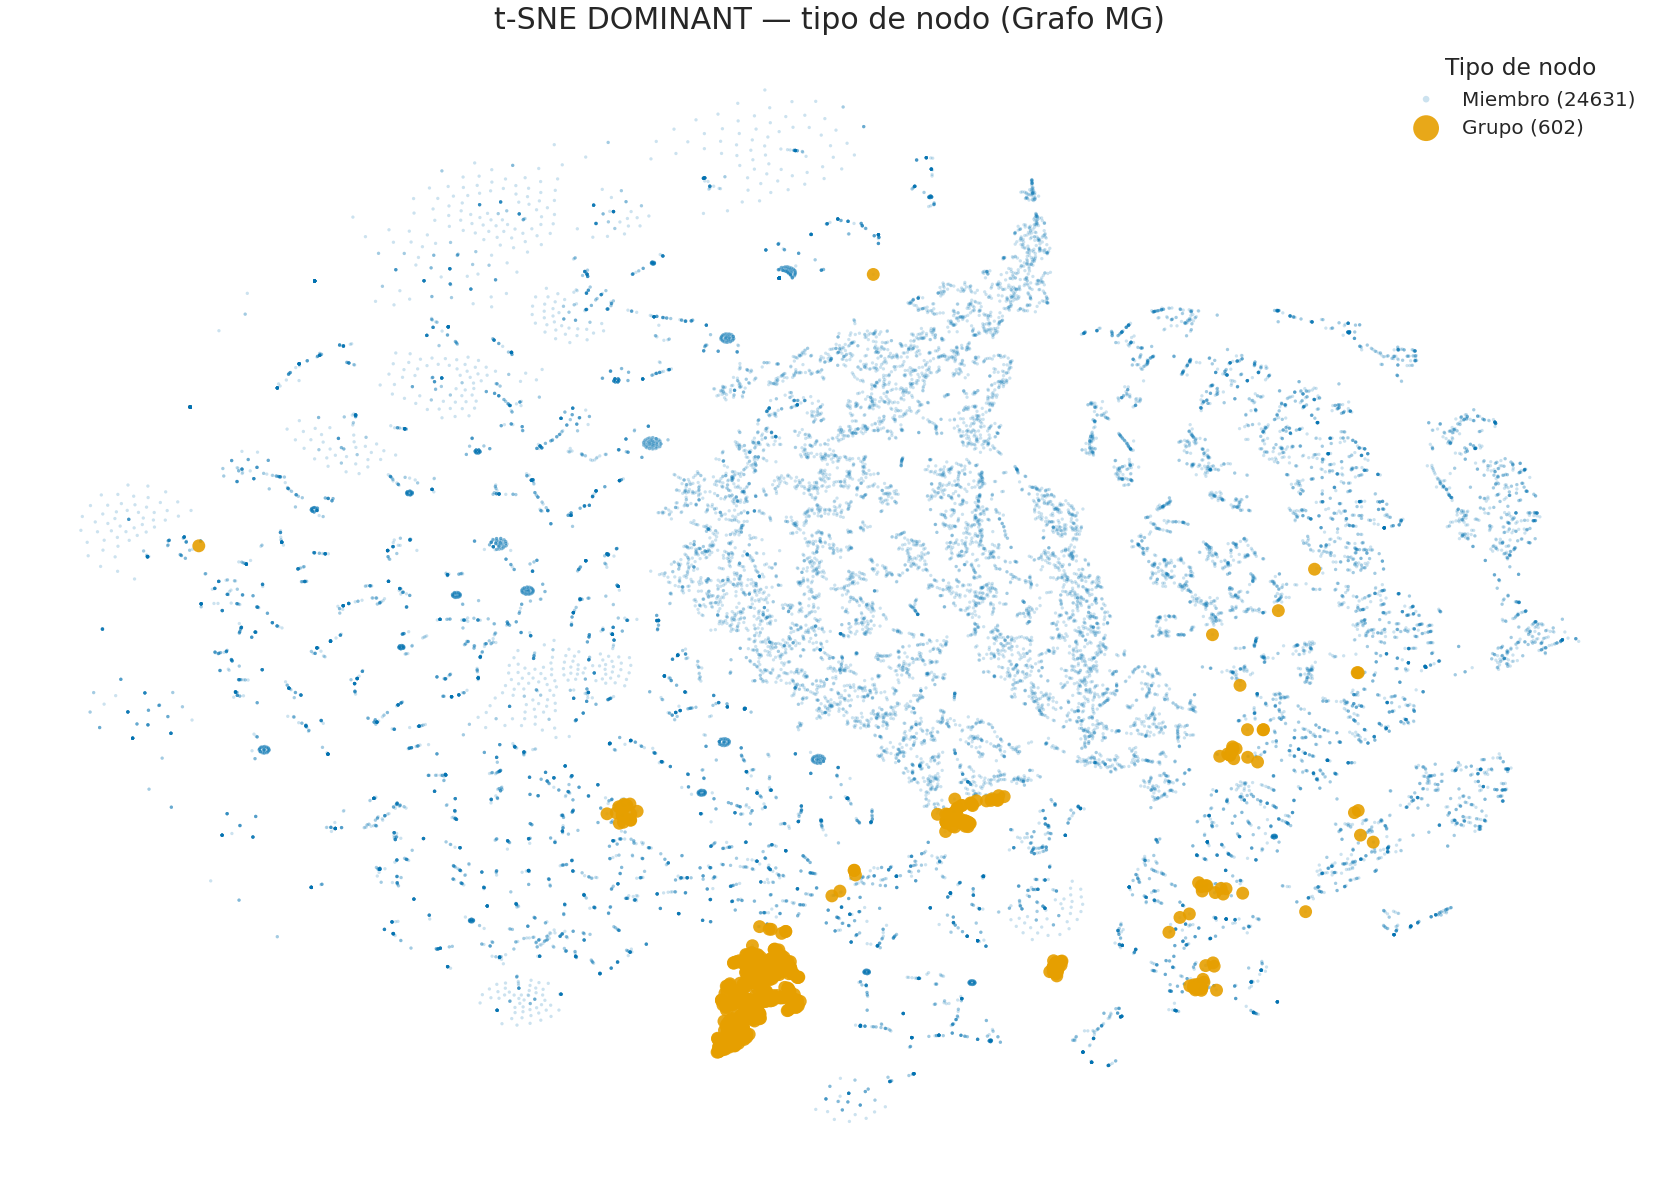

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_type_MG.png


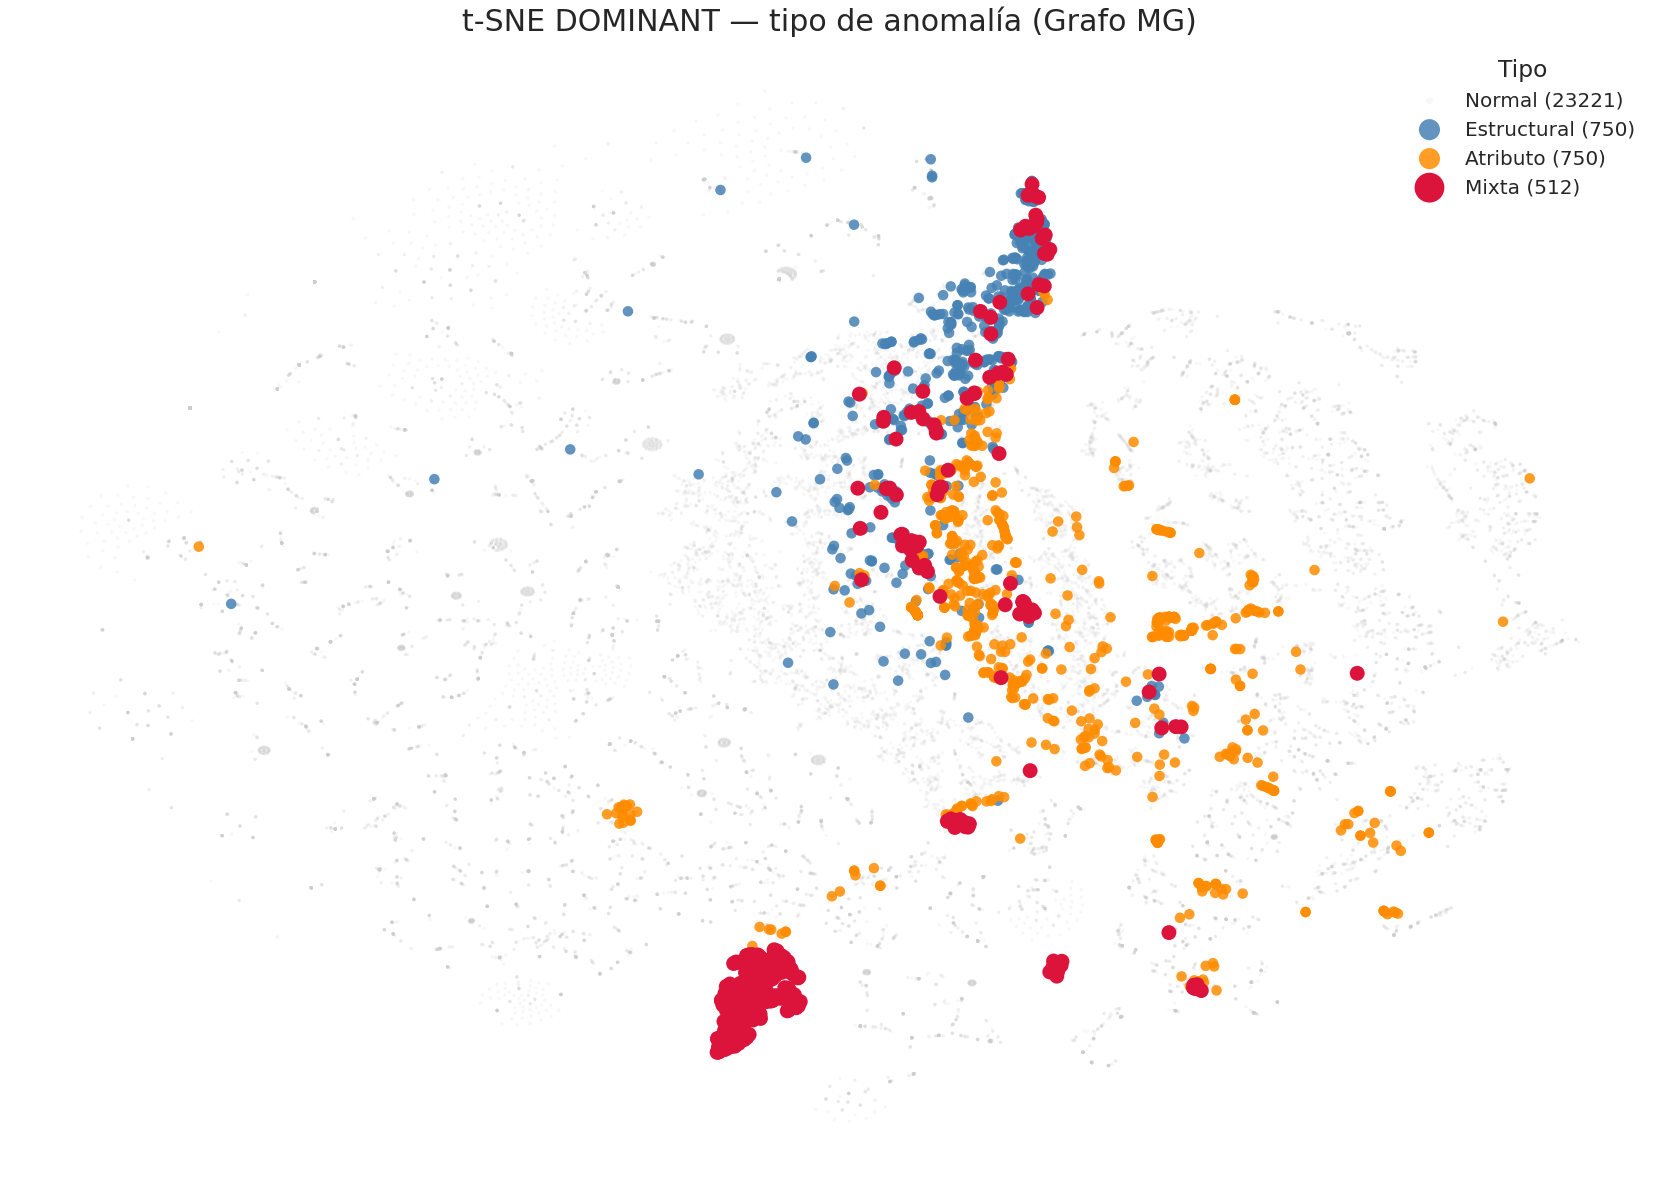

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_score_MG.png


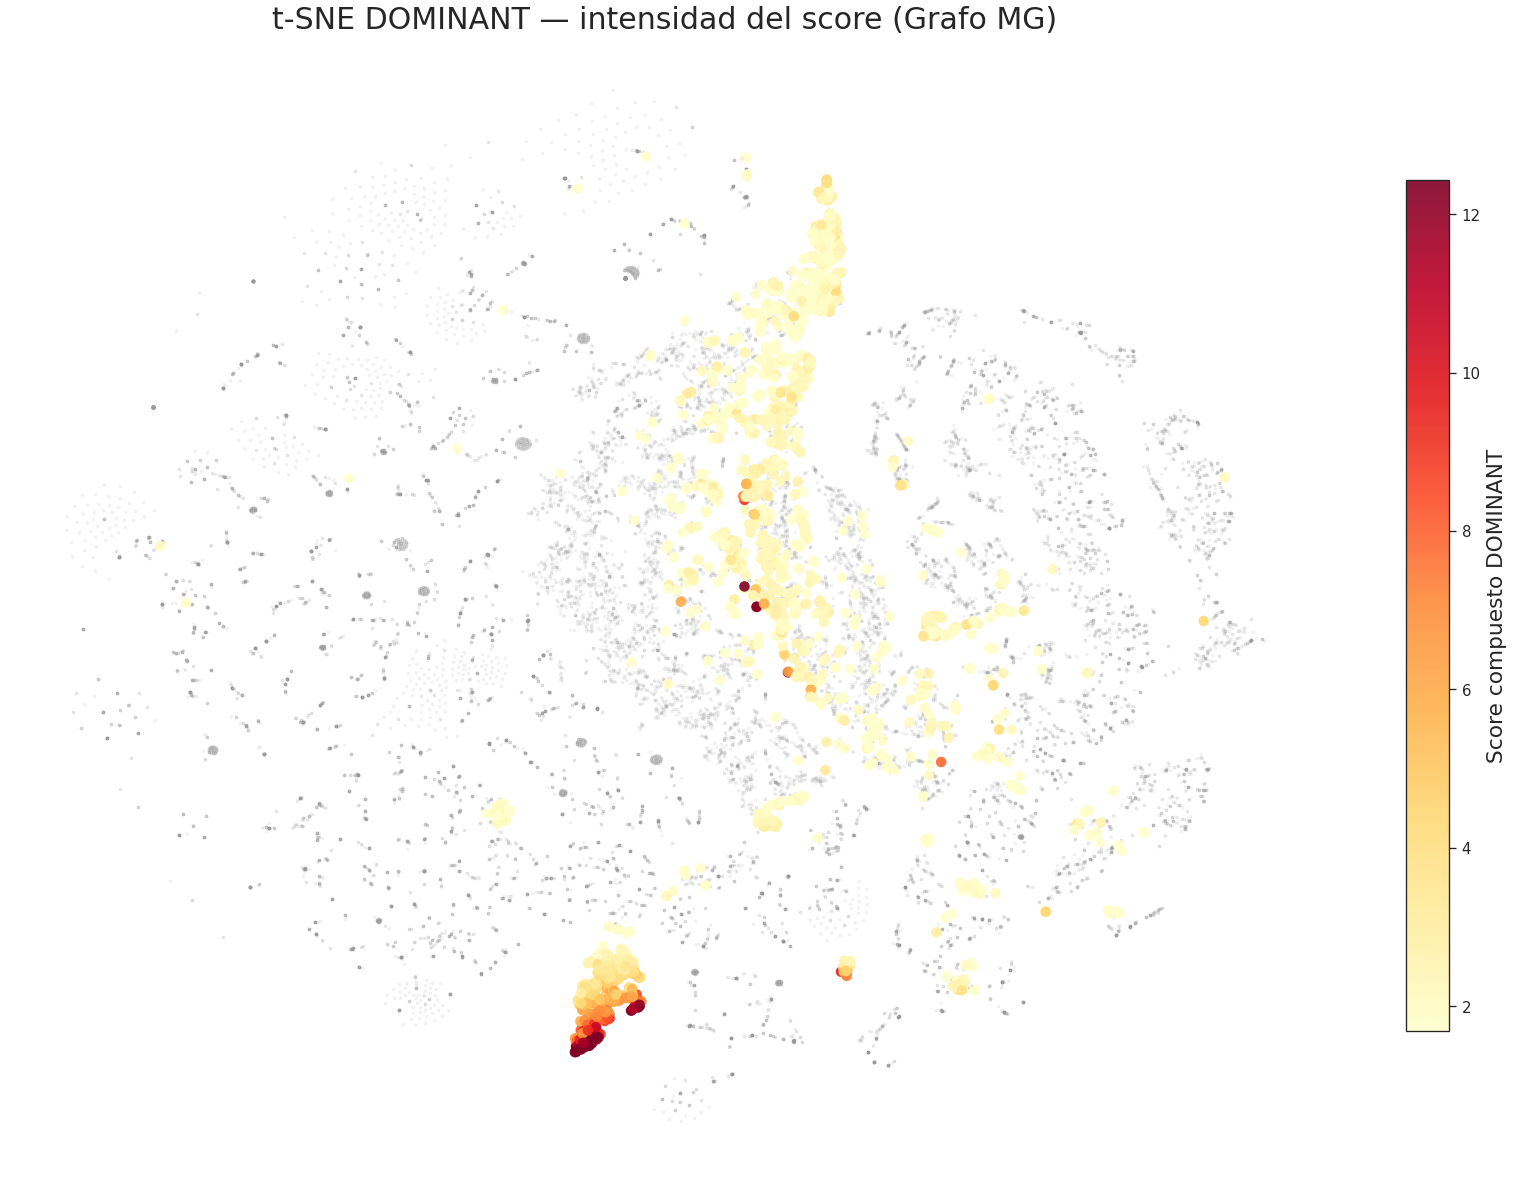

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_profile_MG.png


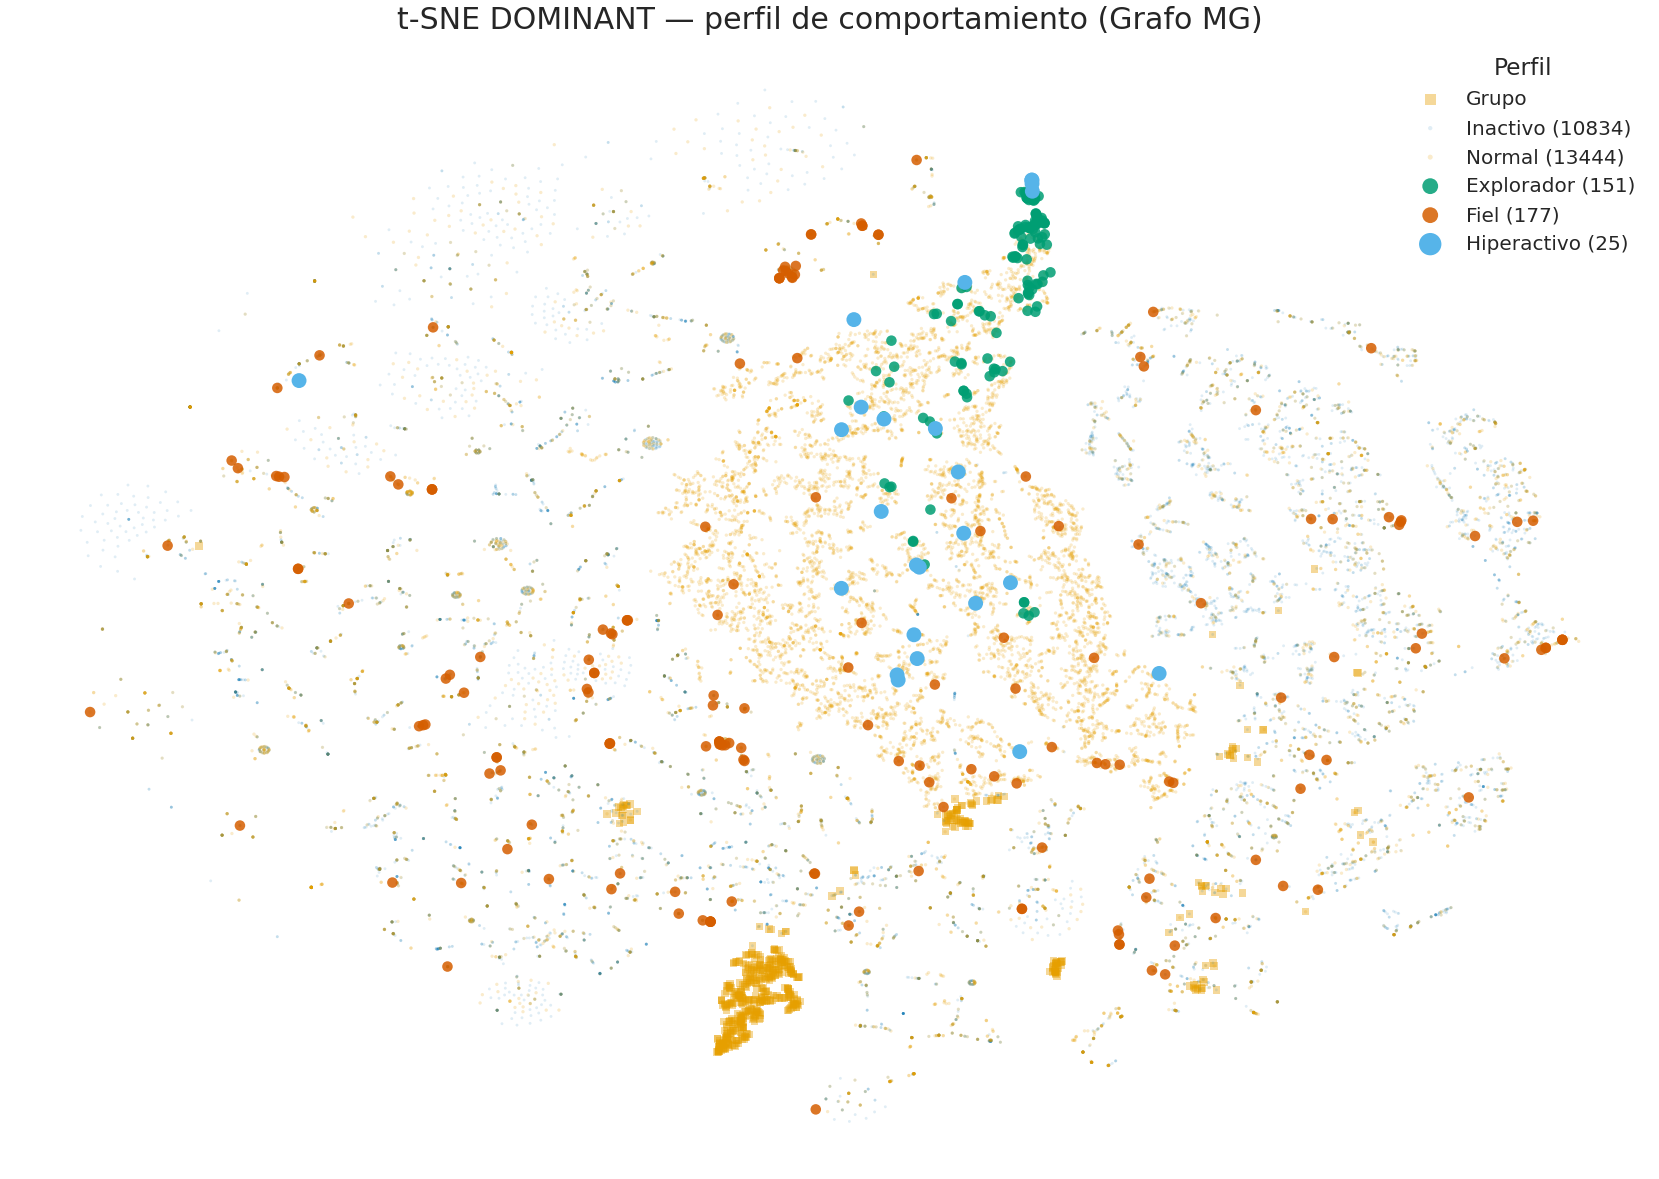

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_dominant_tsne_degree_MG.png


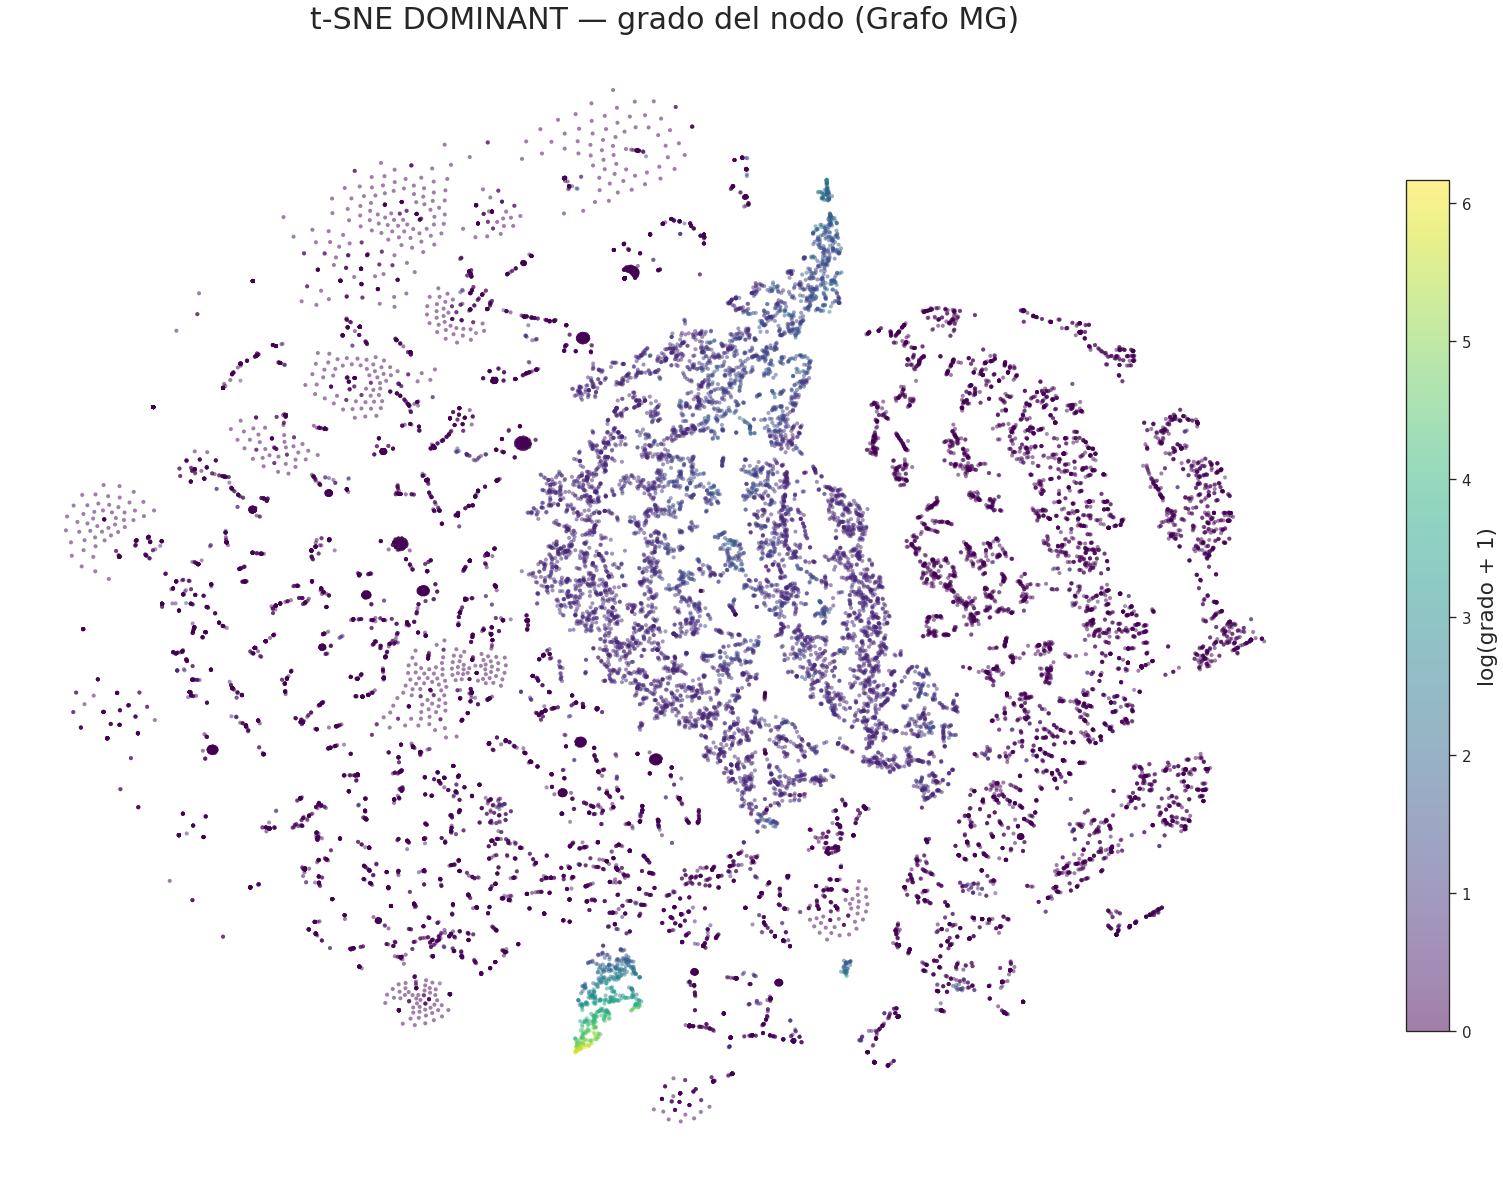

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_node_type_MG.png


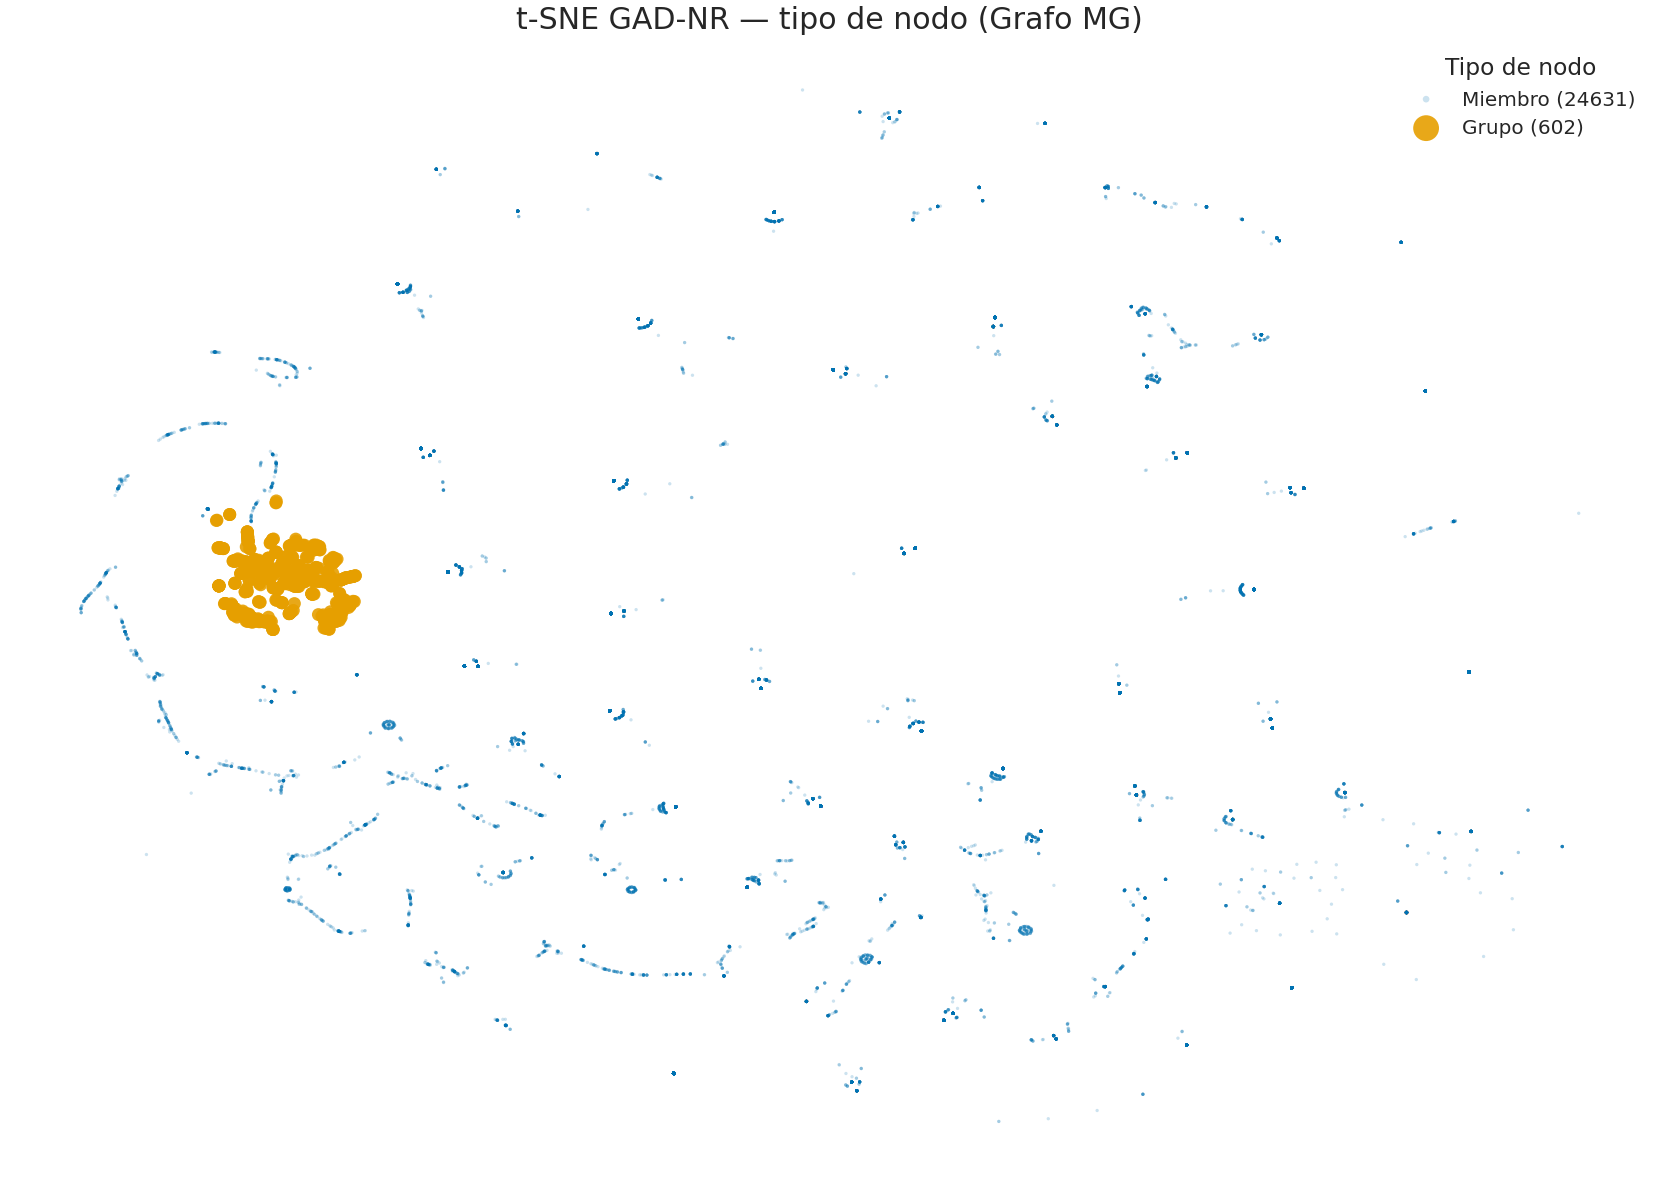

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_type_MG.png


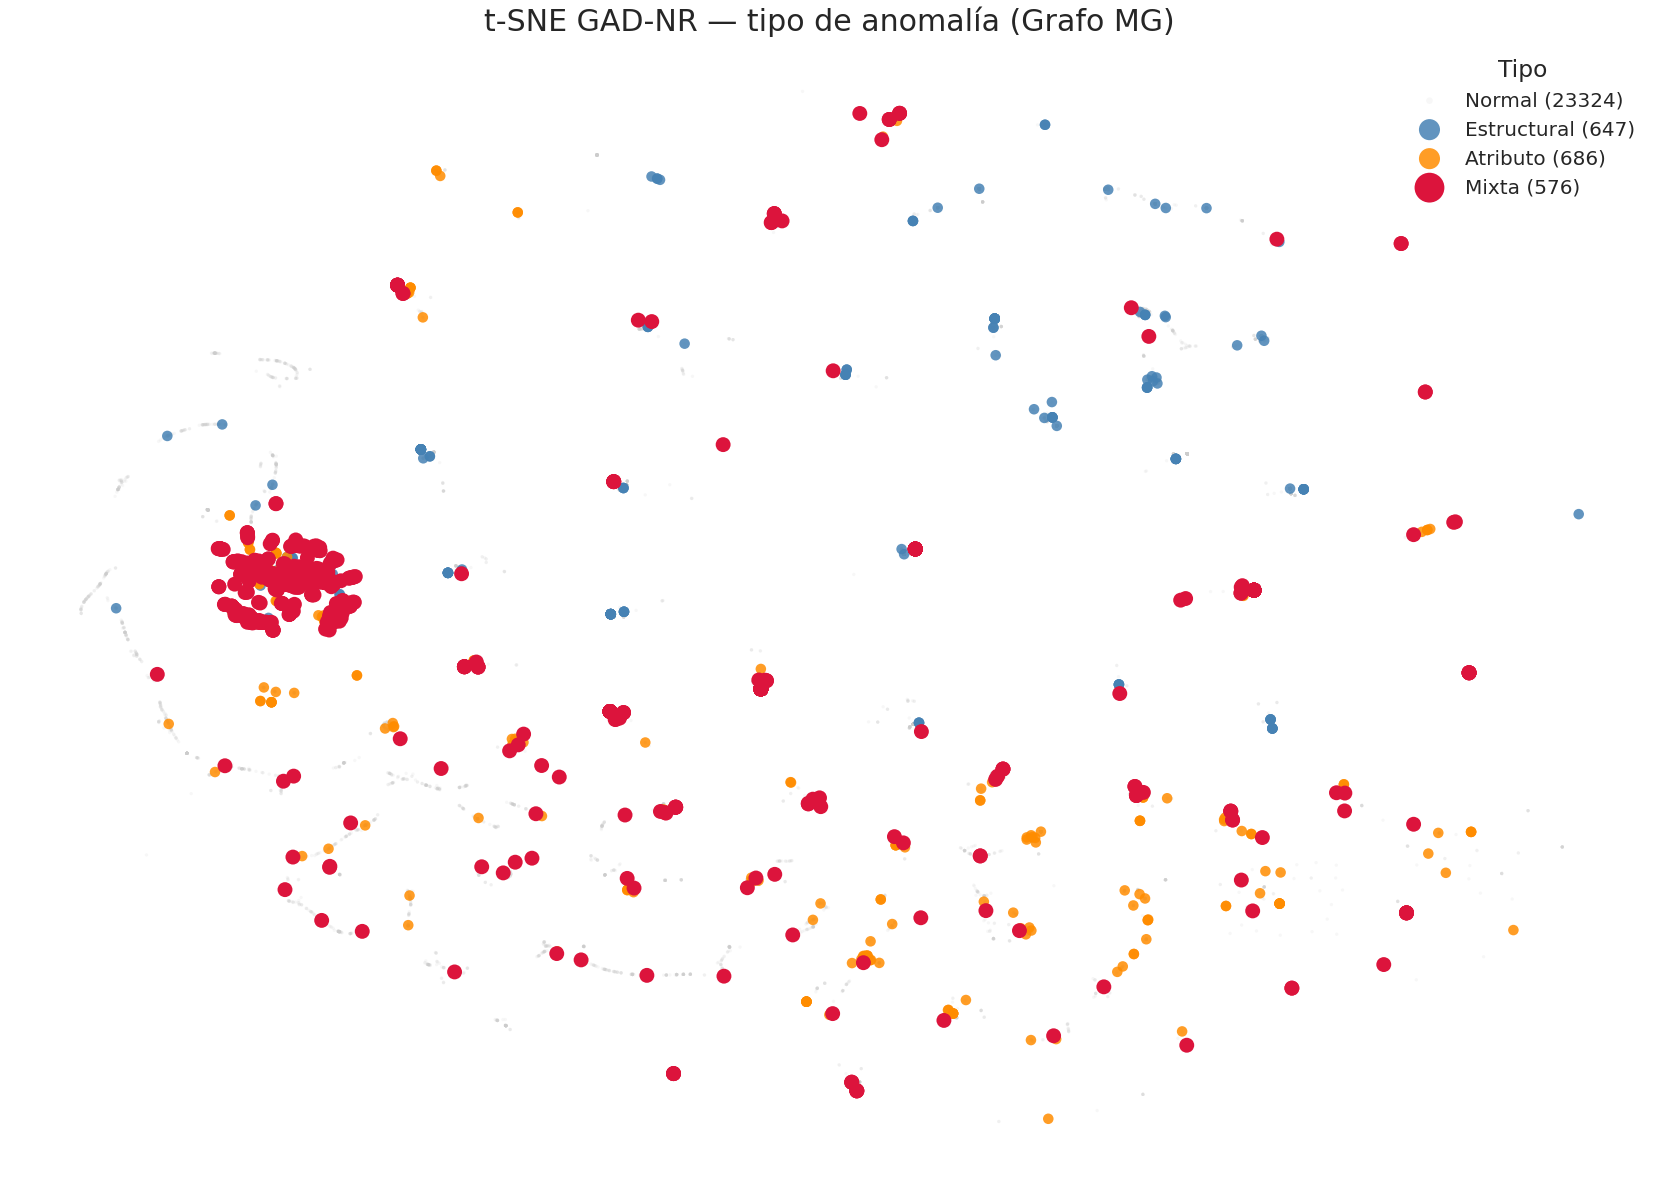

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_score_MG.png


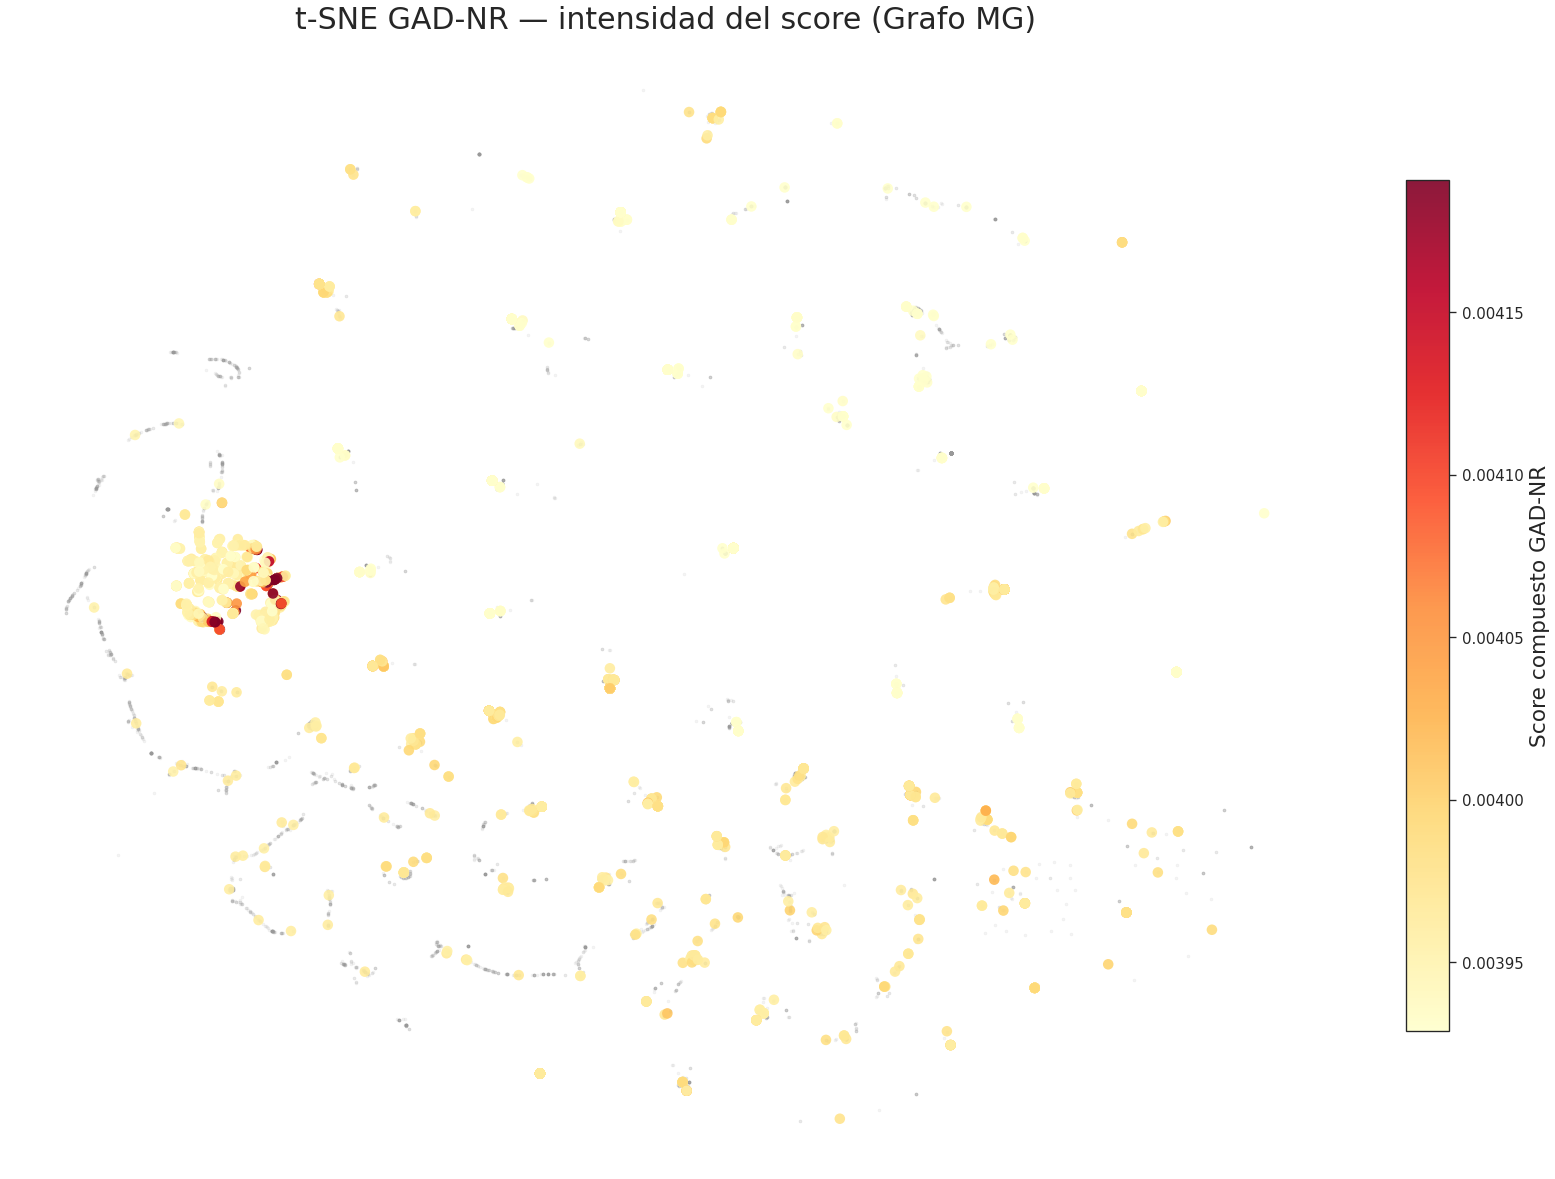

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_profile_MG.png


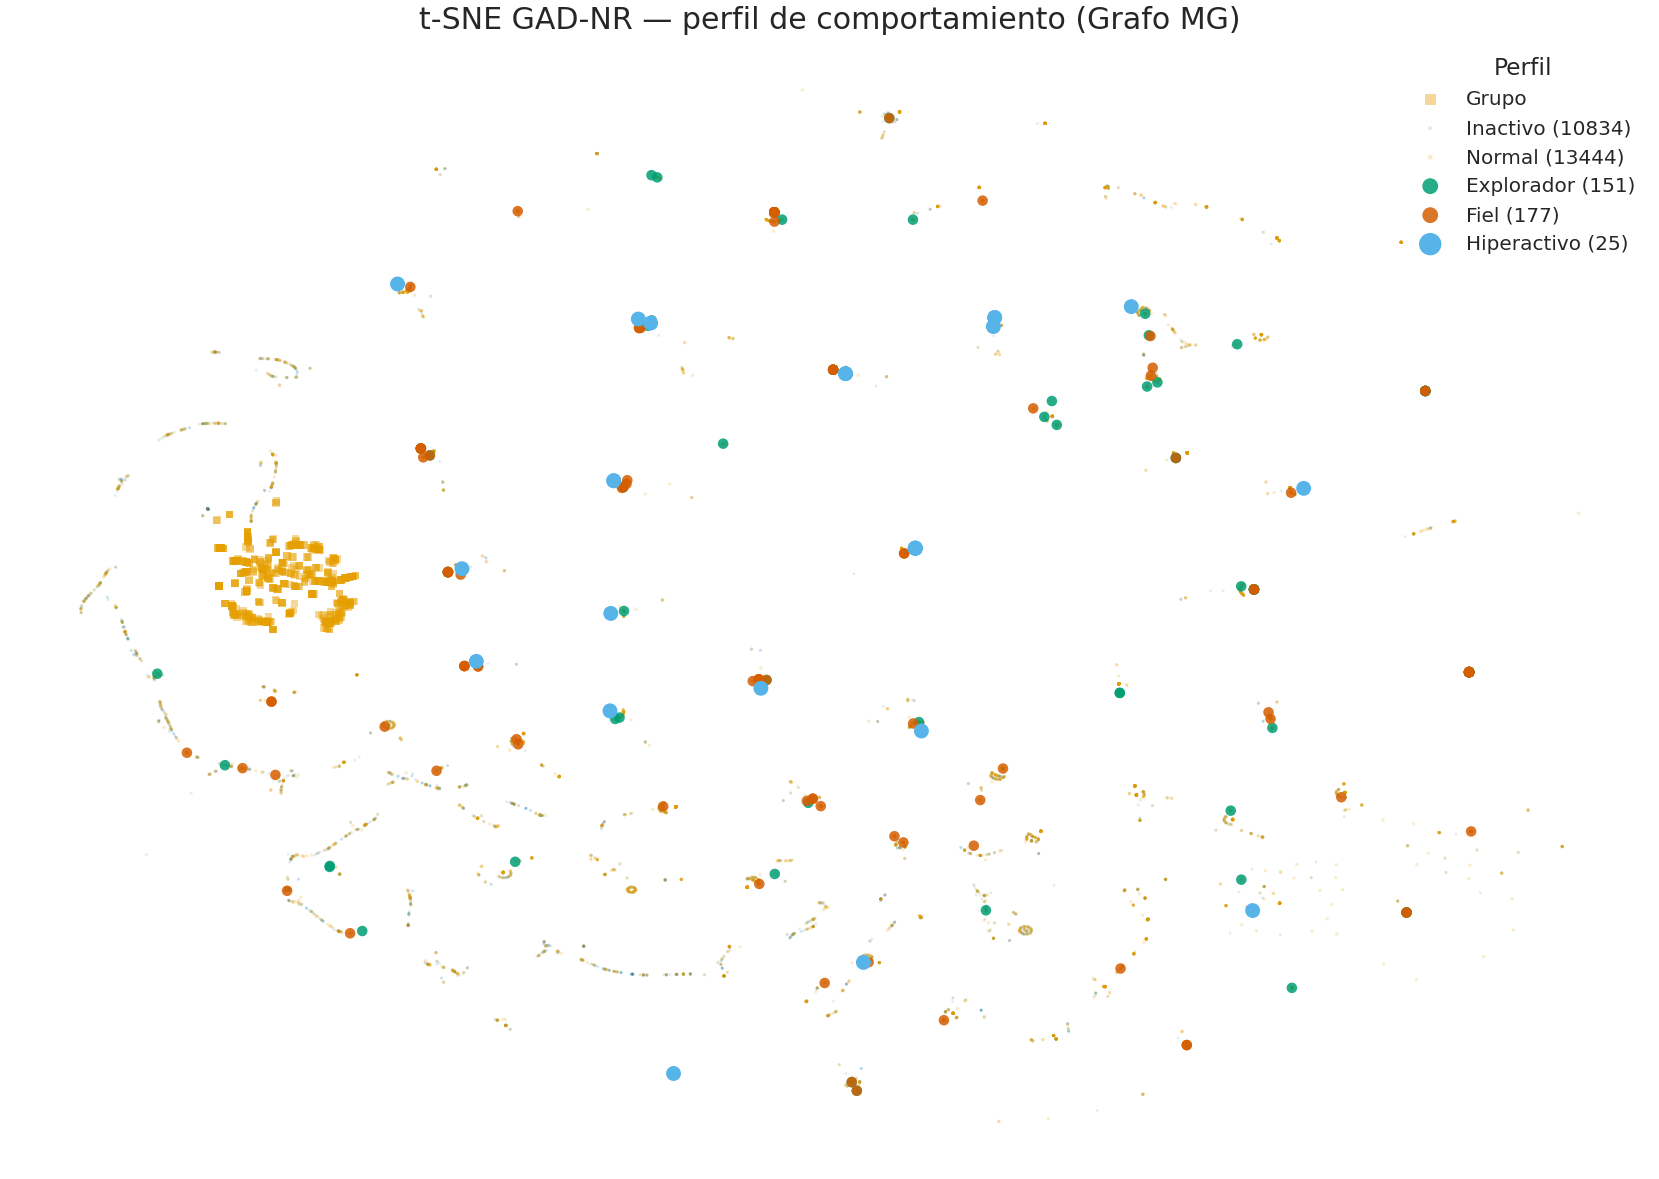

[viz] saved -> C:\Personal\MCD\TFM\results\figures\07_gadnr_tsne_degree_MG.png


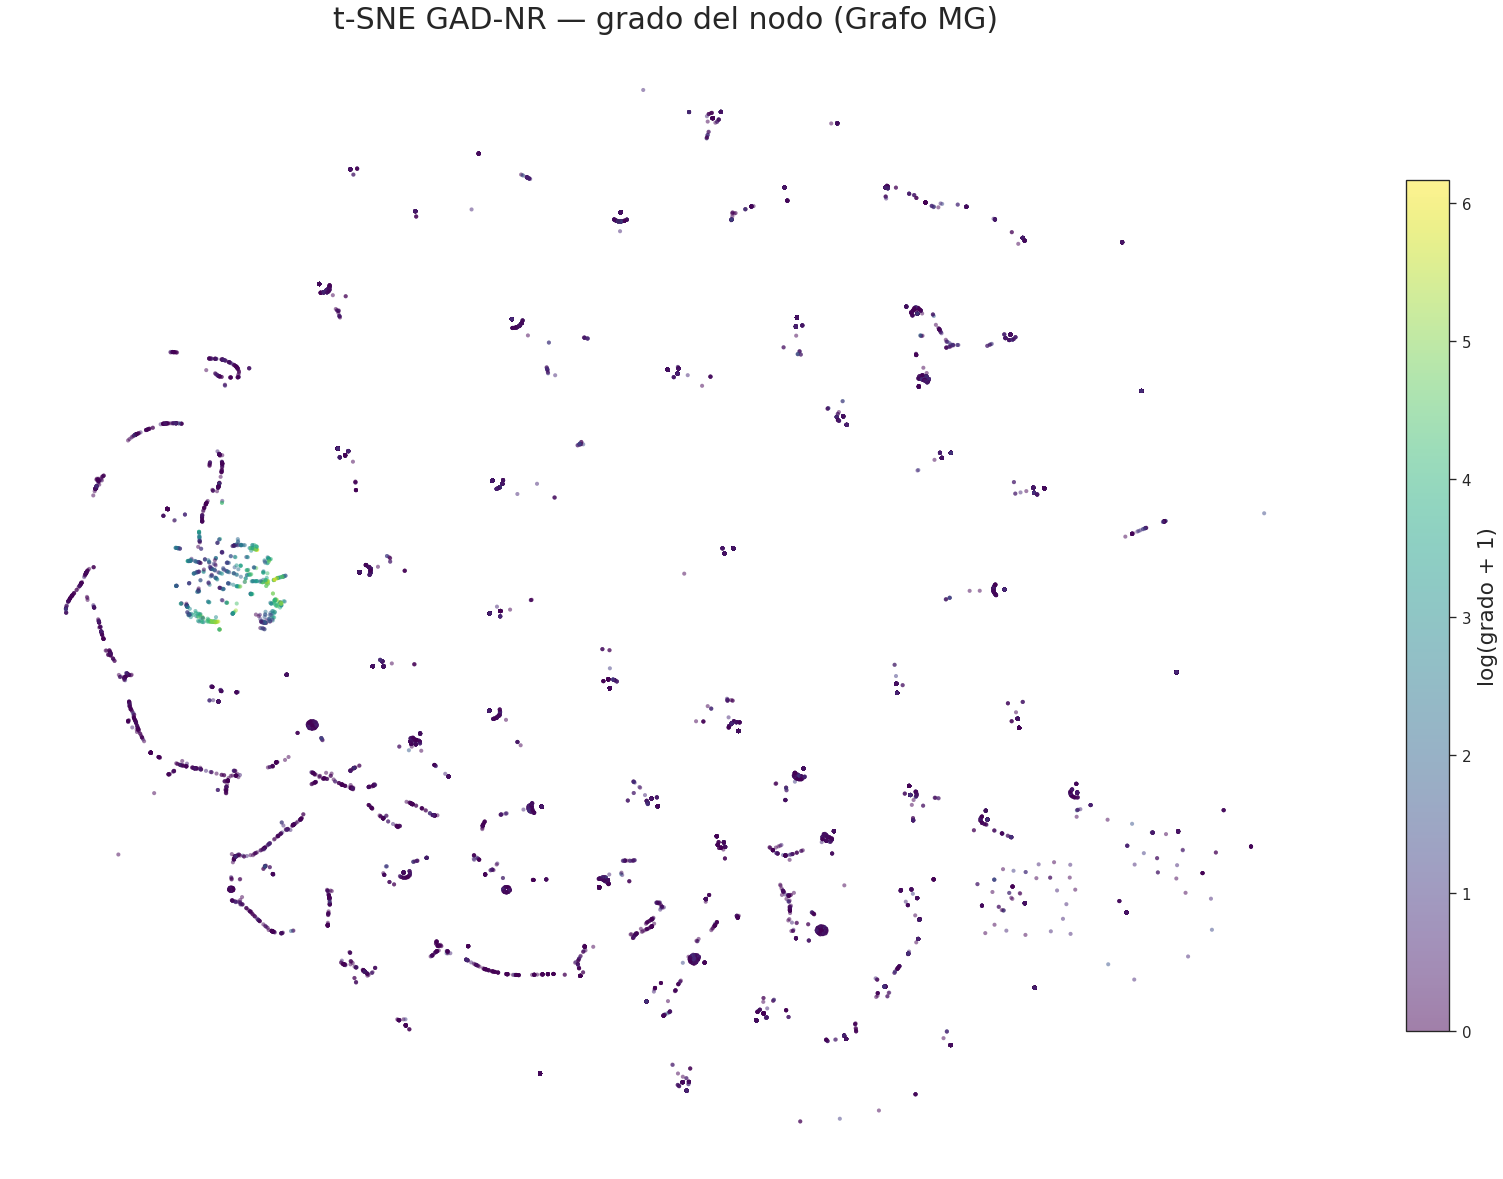

In [48]:
def plot_tsne_panel_mg(tsne_coords, scores_df, model_name, type_col, score_col,
                       figname_prefix, members_scores_df=None):
    """Genera las cinco vistas t-SNE para el grafo MG."""
    FONT_TSNE = {'title': 18, 'axis_label': 13, 'legend': 12, 'annotation': 10}

    def remove_all_spines(ax):
        for spine in ax.spines.values():
            spine.set_visible(False)

    is_member = (scores_df['node_type'] == 'member').values
    is_group  = (scores_df['node_type'] == 'group').values

    # ── Vista 1: tipo de nodo ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[is_member, 0], tsne_coords[is_member, 1],
               s=4, alpha=0.20, color=PALETTE['M'], label=f'Miembro ({is_member.sum()})',
               zorder=1, edgecolors='none')
    ax.scatter(tsne_coords[is_group, 0], tsne_coords[is_group, 1],
               s=60, alpha=0.90, color=PALETTE['G'], label=f'Grupo ({is_group.sum()})',
               zorder=3, edgecolors='none')
    ax.set_title(f't-SNE {model_name} — tipo de nodo (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo de nodo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2, markerscale=2.0, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_node_type_MG.png')
    plt.show()

    # ── Vista 2: tipo de anomalía ─────────────────────────────────────────
    style_by_type = {
        'Normal':      ('#cccccc', 0.15,  4),
        'Estructural': ('steelblue', 0.85, 40),
        'Atributo':    ('darkorange', 0.85, 40),
        'Mixta':       ('crimson', 1.00, 80),
    }
    fig, ax = plt.subplots(figsize=(14, 10))
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})', zorder=zorder, edgecolors='none')
    ax.set_title(f't-SNE {model_name} — tipo de anomalía (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2, markerscale=2.0, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_MG.png')
    plt.show()

    # ── Vista 3: score compuesto ──────────────────────────────────────────
    anom_mask   = scores_df[type_col] != 'Normal'
    normal_mask = ~anom_mask
    vmin_val = scores_df.loc[anom_mask, score_col].quantile(0.20)
    vmax_val = scores_df.loc[anom_mask, score_col].quantile(0.98)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=3, alpha=0.10, color=PALETTE['neutral'], zorder=1)
    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=40, alpha=0.90, cmap=CMAP_HEAT, zorder=3,
        vmin=vmin_val, vmax=vmax_val, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_MG.png')
    plt.show()

    # ── Vista 4: perfil de comportamiento (miembros) ──────────────────────
    if members_scores_df is not None:
        perfil_colors_tsne = {
            'Inactivo':    CAT_COLORS[0],
            'Normal':      CAT_COLORS[1],
            'Explorador':  CAT_COLORS[2],
            'Fiel':        CAT_COLORS[3],
            'Hiperactivo': CAT_COLORS[4],
        }
        perfil_sizes = {
            'Inactivo': 3, 'Normal': 4, 'Explorador': 40,
            'Fiel': 40, 'Hiperactivo': 80
        }
        perfil_alphas = {
            'Inactivo': 0.12, 'Normal': 0.20, 'Explorador': 0.85,
            'Fiel': 0.85, 'Hiperactivo': 1.00
        }

        fig, ax = plt.subplots(figsize=(14, 10))
        # Grupos en gris de fondo
        ax.scatter(tsne_coords[is_group, 0], tsne_coords[is_group, 1],
                   s=20, alpha=0.40, color=PALETTE['G'],
                   label='Grupo', zorder=1, edgecolors='none', marker='s')

        for perfil in ['Inactivo', 'Normal', 'Explorador', 'Fiel', 'Hiperactivo']:
            member_idxs = members_scores_df[members_scores_df['perfil'] == perfil]['idx'].values
            mask = np.isin(np.arange(len(scores_df)), member_idxs)
            if mask.sum() == 0:
                continue
            ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                       s=perfil_sizes[perfil], alpha=perfil_alphas[perfil],
                       color=perfil_colors_tsne[perfil],
                       label=f'{perfil} ({mask.sum()})',
                       zorder=3 if perfil != 'Inactivo' else 2,
                       edgecolors='none')

        ax.set_title(f't-SNE {model_name} — perfil de comportamiento (Grafo MG)',
                     fontsize=FONT_TSNE['title'])
        ax.legend(title='Perfil', fontsize=FONT_TSNE['legend'], frameon=False,
                  title_fontsize=FONT_TSNE['legend'] + 2, markerscale=1.5, loc='upper right')
        ax.set_xticks([]); ax.set_yticks([])
        remove_all_spines(ax)
        plt.tight_layout()
        save_figure(fig, f'{figname_prefix}_tsne_profile_MG.png')
        plt.show()

    # ── Vista 5: grado del nodo ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=6, alpha=0.50, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — grado del nodo (Grafo MG)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_MG.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel_mg(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='07_dominant',
    members_scores_df=members_scores,
)

# t-SNE GAD-NR
plot_tsne_panel_mg(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='07_gadnr',
    members_scores_df=members_scores,
)


## 10. Guardado de resultados

In [49]:
cols_export = [
    'idx', 'node_id', 'node_type', 'raw_id', 'name', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
    # Peso medio de arista (actividad real)
    'mean_edge_weight',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_MG.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_MG.csv')
print(f'Shape    : {scores_export.shape}')

np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_MG.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    node_ids=np.array(node_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_MG.npz')


Guardado : ../data/results/scores_MG.csv
Shape    : (25233, 21)
Guardado : ../data/results/embeddings_MG.npz


## Resumen del notebook

### Verificación de hipótesis

| Hipótesis | Resultado |
|---|---|
| Lambdas finales = 0.01/7.5/3·10⁻⁹ (invariante al grafo) | ✓ Confirmada |
| `gadnr_feat` degenerada (rango ≈ 0) | ✓ Confirmada |
| `gadnr_h` degenerada (igual que en G) | ✓ Confirmada |
| Señal estructural menos coherente que en G (ρ = 0.986) | ✓ Confirmada (ρ = 0.847) |
| t-SNE separa los dos tipos de nodo | ✓ Confirmada (especialmente en DOMINANT) |

### Resultados principales

**Entrenamiento.** DOMINANT converge en 300 épocas sin inestabilidades (loss: 4.46 → ~1.05). GAD-NR converge con patrón escalonado (saltos en épocas 20, 40, 60...) a loss ~0.003, sin divergencias NaN gracias a `lr=0.001` adoptado desde G.

**Sub-scores DOMINANT.** `dom_struct`: 0.80–30.60 (media 1.39). `dom_attr`: 0.005–59.37 (media 0.38). Correlación entre ambas: ρ = 0.566 — más alta que en M (−0.004) y G (−0.150), probablemente por la heterogeneidad de tipos de nodo que introduce covarianza artificial entre señales.

**Señal estructural** (dom_struct vs gadnr_deg): ρ = 0.847, Jaccard P95 = 0.969. La más robusta del experimento, segunda solo a G (ρ = 0.986).

**Señal de atributo** (dom_attr vs gadnr_feat): ρ = 0.133, Jaccard P95 = 0.241. Baja coherencia por degeneración de gadnr_feat. La señal de atributo válida es exclusivamente dom_attr.

**Heterogeneidad de nodos.** Los grupos tienen scores de DOMINANT 5–10 veces superiores a los miembros. El 79% de los nodos Mixtos son grupos. Los modelos infieren la distinción de tipos de nodo sin haberla recibido explícitamente.

**Perfiles de comportamiento.** Los Exploradores (151 miembros, >10 grupos, baja asistencia) son detectados al 100% como anomalías estructurales por ambos modelos. Los Inactivos son invisibles para la señal estructural. Los Fieles no son anómalos. Los Hiperactivos se detectan al 56–84%.

**Grupos fantasma.** Los grupos con ratio de actividad < 5% tienen frac_P95 = 0 en señal estructural (pocas aristas = fáciles de reconstruir). Son detectables exclusivamente por `dom_attr`: Nashville Social Crew (ratio 0.07%) alcanza P99.5 en atributo.

**Actividad real vs anomalía.** Correlación positiva moderada entre peso medio de arista y scores estructurales (ρ = 0.21–0.28): mayor actividad real → mayor grado en el bipartito → mayor score estructural.

**t-SNE.** DOMINANT separa claramente grupos de miembros y diferencia perfiles de comportamiento en el espacio latente. GAD-NR produce separación de tipos pero sin estructura clara de anomalías — consecuencia del curriculum.

### Salidas

- `scores_MG.csv` — 25.233 nodos × 21 columnas con sub-scores, percentiles y tipologías.
- `embeddings_MG.npz` — embeddings (64 dims) y proyecciones t-SNE de ambos modelos.
- `dominant_MG.pkl`, `gadnr_model_MG.pt`, `arrays_MG.npz`, `members_scores_MG.csv`, `groups_scores_MG.csv` — artefactos para reproducibilidad y notebook 08.


In [50]:
import pickle
import torch
import numpy as np
import pandas as pd
import os

SAVE_PATH = '../data/results/models/'
os.makedirs(SAVE_PATH, exist_ok=True)

# ── DOMINANT — pickle completo ────────────────────────────────────────────
with open(os.path.join(SAVE_PATH, 'dominant_MG.pkl'), 'wb') as f:
    pickle.dump(dominant, f)
print('DOMINANT guardado.')

# ── GAD-NR — state_dict + atributos (Pool no es serializable) ────────────
torch.save(gadnr.model.state_dict(), os.path.join(SAVE_PATH, 'gadnr_model_MG.pt'))
gadnr_attrs = {
    'decision_score_':   gadnr.decision_score_.cpu(),
    'label_':            gadnr.label_.cpu(),
    'lambda_loss1':      gadnr.model.lambda_loss1,
    'lambda_loss2':      gadnr.model.lambda_loss2,
    'lambda_loss3':      gadnr.model.lambda_loss3,
    'neighbor_num_list': gadnr.neighbor_num_list.cpu(),
}
torch.save(gadnr_attrs, os.path.join(SAVE_PATH, 'gadnr_attrs_MG.pt'))
print('GAD-NR guardado.')

# ── Arrays derivados ──────────────────────────────────────────────────────
np.savez(
    os.path.join(SAVE_PATH, 'arrays_MG.npz'),
    dom_struct=dom_struct,
    dom_attr=dom_attr,
    gadnr_h=gadnr_h,
    gadnr_deg=gadnr_deg,
    gadnr_feat=gadnr_feat,
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
)
print('Arrays guardados.')

# ── DataFrames ────────────────────────────────────────────────────────────
scores_df.to_csv(os.path.join(SAVE_PATH, 'scores_df_MG.csv'), index=False)
members_scores.to_csv(os.path.join(SAVE_PATH, 'members_scores_MG.csv'), index=False)
groups_scores.to_csv(os.path.join(SAVE_PATH, 'groups_scores_MG.csv'), index=False)
print('DataFrames guardados.')

print(f'\nTodo guardado en {SAVE_PATH}')
print(f'  dominant_MG.pkl')
print(f'  gadnr_model_MG.pt + gadnr_attrs_MG.pt')
print(f'  arrays_MG.npz')
print(f'  scores_df_MG.csv')
print(f'  members_scores_MG.csv')
print(f'  groups_scores_MG.csv')

DOMINANT guardado.
GAD-NR guardado.
Arrays guardados.
DataFrames guardados.

Todo guardado en ../data/results/models/
  dominant_MG.pkl
  gadnr_model_MG.pt + gadnr_attrs_MG.pt
  arrays_MG.npz
  scores_df_MG.csv
  members_scores_MG.csv
  groups_scores_MG.csv


In [51]:
import pickle
import torch
import numpy as np
import pandas as pd
import os

SAVE_PATH = '../data/results/models/'

# ── DOMINANT — pickle completo ────────────────────────────────────────────
with open(os.path.join(SAVE_PATH, 'dominant_MG.pkl'), 'rb') as f:
    dominant = pickle.load(f)
print('DOMINANT cargado.')

# ── GAD-NR — reinstanciar y cargar pesos ─────────────────────────────────
# IMPORTANTE: necesitas tener el objeto gadnr ya instanciado con los mismos
# hiperparámetros y haber ejecutado gadnr.fit() al menos 1 época antes
# de ejecutar estas líneas para que PyGOD inicialice la arquitectura interna
gadnr_attrs = torch.load(os.path.join(SAVE_PATH, 'gadnr_attrs_MG.pt'))
gadnr.model.load_state_dict(
    torch.load(os.path.join(SAVE_PATH, 'gadnr_model_MG.pt'))
)
gadnr.decision_score_    = gadnr_attrs['decision_score_'].to(device)
gadnr.label_             = gadnr_attrs['label_'].to(device)
gadnr.model.lambda_loss1 = gadnr_attrs['lambda_loss1']
gadnr.model.lambda_loss2 = gadnr_attrs['lambda_loss2']
gadnr.model.lambda_loss3 = gadnr_attrs['lambda_loss3']
gadnr.neighbor_num_list  = gadnr_attrs['neighbor_num_list'].to(device)
print('GAD-NR cargado.')

# ── Arrays derivados ──────────────────────────────────────────────────────
arrays     = np.load(os.path.join(SAVE_PATH, 'arrays_MG.npz'))
dom_struct = arrays['dom_struct']
dom_attr   = arrays['dom_attr']
gadnr_h    = arrays['gadnr_h']
gadnr_deg  = arrays['gadnr_deg']
gadnr_feat = arrays['gadnr_feat']
emb_dom    = arrays['emb_dom']
emb_gadnr  = arrays['emb_gadnr']
tsne_dom   = arrays['tsne_dom']
tsne_gadnr = arrays['tsne_gadnr']
print('Arrays cargados.')

# ── DataFrames ────────────────────────────────────────────────────────────
scores_df      = pd.read_csv(os.path.join(SAVE_PATH, 'scores_df_MG.csv'))
members_scores = pd.read_csv(os.path.join(SAVE_PATH, 'members_scores_MG.csv'))
groups_scores  = pd.read_csv(os.path.join(SAVE_PATH, 'groups_scores_MG.csv'))
print('DataFrames cargados.')

print(f'\nTodo cargado correctamente.')
print(f'  DOM scores : {dom_struct.shape}')
print(f'  GADNR scores: {gadnr_h.shape}')
print(f'  scores_df  : {scores_df.shape}')
print(f'  members_df : {members_scores.shape}')
print(f'  groups_df  : {groups_scores.shape}')
print(f'  emb_dom    : {emb_dom.shape}')
print(f'  tsne_dom   : {tsne_dom.shape}')

DOMINANT cargado.
GAD-NR cargado.
Arrays cargados.


C:\Users\marco\AppData\Local\Temp\ipykernel_67744\2923127588.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gadnr_attrs = torch.load(os.path.join(SAVE_PATH, 'gadnr_att

DataFrames cargados.

Todo cargado correctamente.
  DOM scores : (25233,)
  GADNR scores: (25233,)
  scores_df  : (25233, 25)
  members_df : (24631, 29)
  groups_df  : (602, 28)
  emb_dom    : (25233, 64)
  tsne_dom   : (25233, 2)
